# Speech Command Recognition

Autor: Alberto Calabrese

Mail: alberto.calabrese.2@studenti.unipd.it

# Setup

In [1]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 6.5 MB/s eta 0:00:00


In [2]:
import os
import librosa
import numpy as np
import librosa.display
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import hashlib
import tensorflow as tf
from collections import defaultdict, Counter
from keras import layers, models
import pickle
import json
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import regularizers
import time
from sklearn.preprocessing import label_binarize, MinMaxScaler
from keras.saving import register_keras_serializable
from sklearn.manifold import TSNE
from PIL import ImageFont
import visualkeras
from IPython.display import display, Image 

2025-08-03 20:39:53.209277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754253593.412948      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754253593.468962      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"GPU detected: {device_name}")
else:
    print("GPU not found. Go to Runtime > Change runtime type > GPU")

GPU detected: /device:GPU:0


I0000 00:00:1754253608.284392      19 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [5]:
''' 
Change this controller based on the dataset that is loaded in kaggle 
    If is loaded the dataset preprocessed locally (>1GB) set it to False
    If is loaded the original dataset (>2GB) set it to True to preprocess the data in the notebook

Created this mechanism to save GPU hours
'''
FULL_DATASET = True

In [6]:
if FULL_DATASET:
    BASE_PATH = "/kaggle/input/speech-commands-v0-02/speech_commands_v0.02"
    PROCESSED_DATA_DIR = "/kaggle/working/processed_dataset"
else:
    BASE_PATH = "/kaggle/input/speechcommanddataset"
    PROCESSED_DATA_DIR = "/kaggle/input/speechcommanddataset/processed_dataset"
    
OUTPUT_DATA_DIR = "/kaggle/working"

# Data Preprocessing

In [7]:
MAX_NUM_WAVS_PER_CLASS = 2**27 - 1  # ~134M

def which_set(filename, validation_percentage, testing_percentage):
    """
    Determines which dataset partition a file should belong to.
    This function follows the indications of the dataset creators.
    Args:
    filename: File path of the data sample.
    validation_percentage: How much of the data set to use for validation.
    testing_percentage: How much of the data set to use for testing.

    Returns:
    String, one of 'training', 'validation', or 'testing'.
    """
    base_name = os.path.basename(filename)
    hash_name = re.sub(r'_nohash_.*$', '', base_name)
    hash_name_hashed = hashlib.sha1(hash_name.encode()).hexdigest()
    percentage_hash = ((int(hash_name_hashed, 16) %
                        (MAX_NUM_WAVS_PER_CLASS + 1)) *
                        (100.0 / MAX_NUM_WAVS_PER_CLASS))
    if percentage_hash < validation_percentage:
        result = 'val'
    elif percentage_hash < (testing_percentage + validation_percentage):
        result = 'test'
    else:
        result = 'train'
    return result

In [8]:
class SpeechPreprocessor:
    def __init__(self, dataset_path, output_path= PROCESSED_DATA_DIR,
                 sample_rate=16000, n_mels=40, frame_size=0.025, frame_step=0.010,
                 noise_prob=0.3):
        """
        Initializes the SpeechPreprocessor class.

        Args:
            dataset_path (str): Path to the dataset folder.
            output_path (str): Path to the output folder.
            sample_rate (int): Sampling rate of the audio files.
            n_mels (int): Number of Mel bands to generate.
            frame_size (float): Size of the frame window in seconds.
            frame_step (float): Size of the frame step in seconds.
        """
        self.dataset_path = dataset_path
        self.output_path = output_path
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.frame_size = frame_size
        self.frame_step = frame_step
        self.noise_prob = noise_prob
        self.noise_samples = self._load_noise_samples()

        # Ensure output directories exist
        os.makedirs(self.output_path, exist_ok=True)
        for split in ["train", "val", "test"]:
            os.makedirs(f"{self.output_path}/{split}", exist_ok=True)
        print(f"Initialized SpeechPreprocessor with dataset path: {self.dataset_path} and output path: {self.output_path}")

    def _load_noise_samples(self):
        """
        Loads background noise samples from the dataset.
        Returns:
            list: List of noise samples.
        """
        noise_dir = os.path.join(self.dataset_path, "_background_noise_")
        noises = []
        for fname in os.listdir(noise_dir):
            if fname.endswith(".wav"):
                noise_path = os.path.join(noise_dir, fname)
                y, _ = librosa.load(noise_path, sr=self.sample_rate)
                noises.append(y)
        return noises

    def _time_shift(self, audio, shift_max=0.1):
        """
        Applies a random time shift to the audio signal.
        Args:
            audio (np.ndarray): Audio signal to be shifted.
            shift_max (float): Maximum shift in seconds.
        Returns:
            np.ndarray: Time-shifted audio signal.
        """
        shift = int(random.uniform(-shift_max, shift_max) * self.sample_rate)
        if shift > 0:
            audio = np.pad(audio, (shift, 0), mode='constant')[:len(audio)]
        elif shift < 0:
            audio = np.pad(audio, (0, -shift), mode='constant')[-shift:]
        return audio

    def _spec_augment(self, spectrogram, freq_mask_param=3, time_mask_param=8):
        """
        Applies SpecAugment to the spectrogram.
        Args:
            spectrogram (np.ndarray): Input spectrogram.
            freq_mask_param (int): Maximum frequency mask size.
            time_mask_param (int): Maximum time mask size.
        Returns:
            np.ndarray: Augmented spectrogram.
        """
        spec = np.copy(spectrogram)
        num_mel_channels = spec.shape[0]
        num_time_steps = spec.shape[1]

        # Frequency masking
        for _ in range(1):
            f = random.randint(0, freq_mask_param)
            f0 = random.randint(0, num_mel_channels - f)
            spec[f0:f0 + f, :] = 0

        # Time masking
        for _ in range(1):
            t = random.randint(0, time_mask_param)
            t0 = random.randint(0, num_time_steps - t)
            spec[:, t0:t0 + t] = 0

        return spec

    def _add_noise(self, audio):
        """
        Adds random background noise to the audio signal.
        Args:
            audio (np.ndarray): Audio signal to which noise will be added.
        Returns:
            np.ndarray: Audio signal with added noise.
        """
        # If no noise samples are loaded or noise probability is not met, return original audio
        if not self.noise_samples or random.random() > self.noise_prob:
            return audio

        noise = random.choice(self.noise_samples)
        if len(noise) > len(audio):
            start_idx = random.randint(0, len(noise) - len(audio))
            noise = noise[start_idx:start_idx + len(audio)]
        else:
            noise = np.pad(noise, (0, len(audio) - len(noise)))

        # Random noise level between 0.1x and 0.4x of audio signal
        noise_level = random.uniform(0.1, 0.4)
        return audio + noise_level * noise

    def _get_spectrogram(self, filepath, add_noise=False, apply_time_shift=False, apply_spec_augment=False,
                        time_shift_prob=0.5, spec_augment_prob=0.5):
        """
        Converts a .wav file into a log Mel spectrogram.

        Args:
            filepath (str): Path to the .wav file.
            add_noise (bool): Whether to add background noise to the audio.

        Returns:
            np.ndarray: Log Mel spectrogram of the audio file.
        """
        y, sr = librosa.load(filepath, sr=self.sample_rate)

        if apply_time_shift and random.random() < time_shift_prob:
            y = self._time_shift(y)

        if add_noise:
            y = self._add_noise(y)

        spectrogram = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=self.n_mels,
            hop_length=int(self.frame_step * sr),
            n_fft=int(self.frame_size * sr)
        )
        spectrogram = librosa.power_to_db(spectrogram, ref=np.max)

        if apply_spec_augment and random.random() < spec_augment_prob:
            spectrogram = self._spec_augment(spectrogram)

        # Pad or truncate to fixed width
        target_width = 101
        if spectrogram.shape[1] < target_width:
            spectrogram = np.pad(spectrogram, ((0, 0), (0, target_width - spectrogram.shape[1])), mode="constant")
        else:
            spectrogram = spectrogram[:, :target_width]

        return spectrogram


    def process_audio_files(self):
        """
        Processes all audio files and applies dataset partitioning.
        The processed spectrograms are saved in the output directory.
        The dataset partitioning is done using the official method from the dataset.
        The processed dataset will have the following structure:
        processed_dataset/
        ├── train/ # Training set
        │   ├── class1/
        │   │   ├── file1.npy
        │   │   ├── file2.npy
        │   │   └── ...
        │   ├── class2/
        │   └── ...
        ├── val/ # Validation set
        │   ├── class1/
        │   ├── class2/
        │   └── ...
        └── test/ # Testing set
            ├── class1/
            ├── class2/
            └── ...
        Data augmentation is applied only to the training set with noise addition, time shifting and spec augment.
        """
        print("Processing audio files...")

        noise_count = 0
        time_shift_count = 0
        spec_augment_count = 0

        for label in tqdm(os.listdir(self.dataset_path)):
            label_path = os.path.join(self.dataset_path, label)
            # Skip if the path is not a directory or the label is _background_noise_
            if not os.path.isdir(label_path) or label == "_background_noise_":
                continue

            for filename in os.listdir(label_path):
                if not filename.endswith(".wav"):
                    continue

                filepath = os.path.join(label_path, filename)

                # Determine dataset partition
                dataset_type = which_set(filename, 10, 10)

                # Add noise only for training set
                is_train = (dataset_type == "train")

                # Check if the spectrogram is already saved
                output_dir = os.path.join(self.output_path, dataset_type, label)
                os.makedirs(output_dir, exist_ok=True)

                output_file = os.path.join(output_dir, filename.replace(".wav", ".npy"))

                if os.path.exists(output_file):
                    continue  # Skip if the file already exists

                apply_noise = is_train and (random.random() < self.noise_prob)
                apply_time_shift = is_train and (random.random() < 0.3)
                apply_spec_augment = is_train and (random.random() < 0.3)

                # Convert to spectrogram
                spectrogram = self._get_spectrogram(
                    filepath, apply_noise, is_train, is_train,
                    time_shift_prob=0.3, spec_augment_prob=0.3
                )

                # Normalize
                spectrogram = (spectrogram - np.mean(spectrogram)) / np.std(spectrogram)

                # Save spectrogram
                np.save(output_file, spectrogram)

                # Log the augmented files
                if apply_noise:
                    noise_count += 1
                if apply_time_shift:
                    time_shift_count += 1
                if apply_spec_augment:
                    spec_augment_count += 1

        print("Data processing complete!")

        # Stats summary
        total_processed = sum(
            len([f for f in files if f.endswith(".npy")])
            for split in ["train", "val", "test"]
            for root, _, files in os.walk(os.path.join(self.output_path, split))
        )

        train_total = sum(
            len([f for f in files if f.endswith(".npy")])
            for root, _, files in os.walk(os.path.join(self.output_path, "train"))
        )

        if total_processed > 0:
            print(f"\nSummary of Preprocessing:")
            print(f"- Total samples processed: {total_processed}")

        if train_total > 0:
            print(f"- Total training samples: {train_total}")
            print(f"- Training samples with noise: {noise_count} ({(noise_count / train_total) * 100:.2f}%)")
            print(f"- Training samples with time shift: {time_shift_count} ({(time_shift_count / train_total) * 100:.2f}%)")
            print(f"- Training samples with SpecAugment: {spec_augment_count} ({(spec_augment_count / train_total) * 100:.2f}%)\n")



    def visualize_random_sample(self):
        sample_class = random.choice(os.listdir(f"{self.output_path}/train"))
        sample_file = random.choice(os.listdir(f"{self.output_path}/train/{sample_class}"))

        spectrogram = np.load(f"{self.output_path}/train/{sample_class}/{sample_file}")

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(spectrogram, sr=self.sample_rate,
                                 hop_length=int(self.frame_step * self.sample_rate),
                                 x_axis="time", y_axis="mel")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram of {sample_file}")
        plt.show()

Initialized SpeechPreprocessor with dataset path: /kaggle/input/speech-commands-v0-02/speech_commands_v0.02 and output path: /kaggle/working/processed_dataset
Processing audio files...


100%|██████████| 40/40 [14:22<00:00, 21.55s/it]


Data processing complete!

Summary of Preprocessing:
- Total samples processed: 105829
- Total training samples: 84843
- Training samples with noise: 25478 (30.03%)
- Training samples with time shift: 25434 (29.98%)
- Training samples with SpecAugment: 25362 (29.89%)



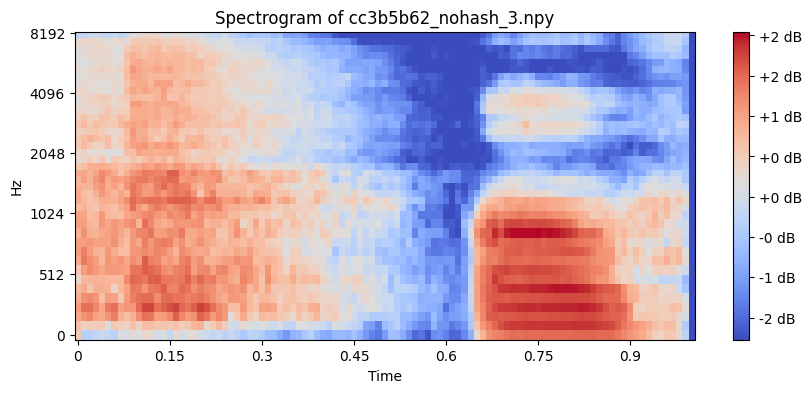

In [9]:
def preprocess():

    # Create the preprocessor instance
    processor = SpeechPreprocessor(BASE_PATH)

    # Process all audio files
    processor.process_audio_files()

    # Visualize a sample spectrogram as a sanity check
    processor.visualize_random_sample()

if FULL_DATASET:
    preprocess()

In [10]:
def get_class_weights(train_path):
    """
    Computes class weights based on the number of .wav files in each class directory.

    Args:
        train_path (str): Path to the train dataset folder.

    Returns:
        class_weights (dict): {class_index: weight}
        label_to_index (dict): {label_name: index}
        index_to_label (dict): {index: label_name}
    """
    # List class names
    class_names = sorted([
        d for d in os.listdir(train_path)
        if os.path.isdir(os.path.join(train_path, d))
    ])

    label_to_index = {label: idx for idx, label in enumerate(class_names)}
    index_to_label = {idx: label for label, idx in label_to_index.items()}

    class_counts = Counter()
    for label in class_names:
        label_dir = os.path.join(train_path, label)
        num_files = len([f for f in os.listdir(label_dir) if f.endswith(".npy")])
        class_counts[label] = num_files

    y_all = np.concatenate([[label] * class_counts[label] for label in class_names])

    weights = compute_class_weight(class_weight="balanced", classes=np.array(class_names), y=y_all)
    class_weights = {label_to_index[class_names[i]]: weights[i] for i in range(len(class_names))}

    return class_weights, label_to_index, index_to_label

train_path = PROCESSED_DATA_DIR + "/train"

class_weights, label_to_index, index_to_label = get_class_weights(train_path)

In [11]:
with open('label_to_index.json', 'w') as f:
    json.dump(label_to_index, f)

print(label_to_index)

{'backward': 0, 'bed': 1, 'bird': 2, 'cat': 3, 'dog': 4, 'down': 5, 'eight': 6, 'five': 7, 'follow': 8, 'forward': 9, 'four': 10, 'go': 11, 'happy': 12, 'house': 13, 'learn': 14, 'left': 15, 'marvin': 16, 'nine': 17, 'no': 18, 'off': 19, 'on': 20, 'one': 21, 'right': 22, 'seven': 23, 'sheila': 24, 'six': 25, 'stop': 26, 'three': 27, 'tree': 28, 'two': 29, 'up': 30, 'visual': 31, 'wow': 32, 'yes': 33, 'zero': 34}


# Data Loading and Utils

In [12]:
def load_dataset(split_path, label_to_index, input_shape=(40, 101), shuffle=True):
    data = []
    labels = []

    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if not os.path.isdir(label_path):
            continue

        for fname in os.listdir(label_path):
            if not fname.endswith(".npy"):
                continue

            file_path = os.path.join(label_path, fname)
            spectrogram = np.load(file_path).astype(np.float32)

            # Ensure shape matches
            if spectrogram.shape != input_shape:
                print(f"Skipping {file_path} due to shape mismatch: {spectrogram.shape}")
                continue

            data.append(spectrogram)
            labels.append(label_to_index[label])


    data = np.array(data)[..., np.newaxis]  # Add channel dim
    labels = np.array(labels)

    dataset = tf.data.Dataset.from_tensor_slices((data, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(data))

    return dataset, data, labels

In [13]:
train_ds, _, _ = load_dataset(os.path.join(PROCESSED_DATA_DIR, "train"), label_to_index)
val_ds, _, _ = load_dataset(os.path.join(PROCESSED_DATA_DIR, "val"), label_to_index, shuffle=False)
test_ds, X_test, y_test = load_dataset(os.path.join(PROCESSED_DATA_DIR, "test"), label_to_index, shuffle=False)


BATCH_SIZE = 64
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1754254495.150578      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [14]:
def save_and_plot_results(history, model, model_name, saving_dir, transformer = False):
    """
    Save the model training history, its metadata and plots results for accuracy and loss.
    Also, visualize and save the model architecture using visualkeras with custom text.
    Args:
        history
        model
        model_name (str)
        saving_dir (str)
    """
    print(f"\n--- Saving results for model: {model_name} ---")
    
    os.makedirs(saving_dir, exist_ok=True)

    history_dict = history.history

    plt.figure(figsize=(10, 6))
    plt.plot(history_dict['loss'], label='Training Loss', marker='o')
    plt.plot(history_dict['val_loss'], label='Validation Loss', marker='o')
    plt.title(f"Loss: {model_name.replace('_', ' ').title()}", fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    loss_path = os.path.join(saving_dir, f"{model_name}_loss.png")
    plt.savefig(loss_path)
    plt.show()
    print(f"Loss plot saved to {loss_path}")

    plt.figure(figsize=(10, 6))
    plt.plot(history_dict['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title(f"Accuracy: {model_name.replace('_', ' ').title()}", fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    accuracy_path = os.path.join(saving_dir, f"{model_name}_accuracy.png")
    plt.savefig(accuracy_path)
    plt.show()
    print(f"Accuracy plot saved to {accuracy_path}")

    history_path = os.path.join(saving_dir, "training_history.pkl")
    with open(history_path, "wb") as f:
        pickle.dump(history_dict, f)
    print(f"Training history saved to {history_path}")

    best_epoch_idx = np.argmax(history_dict['val_accuracy'])
    best_train_acc = history_dict['accuracy'][best_epoch_idx]
    best_val_acc = history_dict['val_accuracy'][best_epoch_idx]
    effective_epochs = best_epoch_idx + 1

    metadata = {
        "model_name": model_name,
        "epochs_trained": int(effective_epochs),
        "best_train_acc": round(float(best_train_acc), 4),
        "best_val_acc": round(float(best_val_acc), 4),
        "input_shape": list(model.input_shape),
        "output_shape": list(model.output_shape),
        "num_params": int(model.count_params())
    }
    metadata_path = os.path.join(saving_dir, f"metadata_{model_name}.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata saved to {metadata_path}")

    if transformer == False:
        print(f"\n--- Plotting model architecture for: {model_name} ---")
        architecture_path = os.path.join(saving_dir, f"{model_name}_architecture.png")
        architecture_path_custom = os.path.join(saving_dir, f"{model_name}_architecture_custom.png")
            
        visualkeras.layered_view(model, legend=True, to_file=architecture_path)
        visualkeras.layered_view(model, legend=True, to_file=architecture_path_custom, show_dimension=True)
        print("Model architecture plot saved")
        display(Image(filename=architecture_path_custom))

# Models

## Baseline CNN


#### **Model Purpose and Design Philosophy**
The Baseline Convolutional Neural Network (CNN) is designed to serve as a foundational benchmark for the task. Its architecture is inspired by established CNN models for audio and image classification, providing a simple approach to validate the dataset and the processing pipeline. The primary goal of this model is to establish a performance baseline against which more complex and novel architectures can be compared.

---

#### **Architectural Details**
The model is implemented as a sequential stack of layers, logically divided into a convolutional feature extractor followed by a fully connected classifier.

* **Feature Extractor:** The initial stage processes the input log-mel spectrogram (40x101). It consists of two `Conv2D` layers with 32 and 64 filters, respectively, using a (3,3) kernel size and ReLU activation function. These layers are designed to capture hierarchical features, starting from low-level patterns (e.g., edges, textures) to more complex acoustic motifs. Each convolutional layer is followed by `BatchNormalization` to stabilize training and accelerate convergence. A single `MaxPooling2D` layer with a (2,2) pool size is applied after the second convolutional block to reduce the spatial dimensionality of the feature maps and provide a degree of translation invariance.

* **Classifier:** The 2D feature maps from the extractor are flattened into a 1D vector. This vector is then processed by a fully connected `Dense` layer with 128 neurons and ReLU activation. The final output is produced by a `Dense` layer with a `softmax` activation function to generate class probabilities.

* **Regularization:** To mitigate overfitting, two `Dropout` layers are incorporated. The first, with a rate of 0.25, is applied after the feature extraction stage, while the second, with a higher rate of 0.5, is placed before the final classification layer.

* **Disadvantages:**
    * **Limited Temporal Modeling:** The architecture treats the spectrogram as a static image and does not explicitly model long-range temporal dependencies across the entire audio clip, which could be a limitation compared to recurrent or attention-based models.
    * **Shallow Feature Hierarchy:** With only two convolutional layers, its ability to learn highly abstract and complex feature representations is limited compared to deeper networks like ResNets.

In [15]:
def baseline_cnn(input_shape=(40, 101, 1), num_classes = len(label_to_index)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    lr = 1e-3
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss = 'sparse_categorical_crossentropy'
    metrics = ['accuracy']
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

In [16]:
model = baseline_cnn(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "baseline_cnn"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb])

Epoch 1/20


I0000 00:00:1754254508.932320      74 service.cc:148] XLA service 0x7e2b40003e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754254508.933102      74 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1754254509.291224      74 cuda_dnn.cc:529] Loaded cuDNN version 90300


  16/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.0318 - loss: 10.3392

I0000 00:00:1754254513.310796      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.0212 - loss: 3.8805 - val_accuracy: 0.0226 - val_loss: 3.5149 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.0322 - loss: 3.5472 - val_accuracy: 0.0518 - val_loss: 3.4909 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.0339 - loss: 3.5257 - val_accuracy: 0.0275 - val_loss: 3.5028 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.0357 - loss: 3.5298 - val_accuracy: 0.0389 - val_loss: 3.4741 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.0294 - loss: 3.5307 - val_accuracy: 0.0584 - val_loss: 3.4605 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.0321 - loss: 3.5218 - val_accuracy: 0.0601 - val_loss: 3.4229 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.0395 

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 99, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 99, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 55296)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,078,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,304,811 (81.27 MB)

 Trainable params: 7,101,539 (27.09 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 14,203,080 (54.18 MB)

In [18]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0499 - loss: 3.3349
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0490 - loss: 3.3719

Validation accuracy: 0.0612
Validation loss: 3.3142

Test accuracy: 0.0613
Test loss: 3.3636



--- Saving results for model: baseline_cnn ---


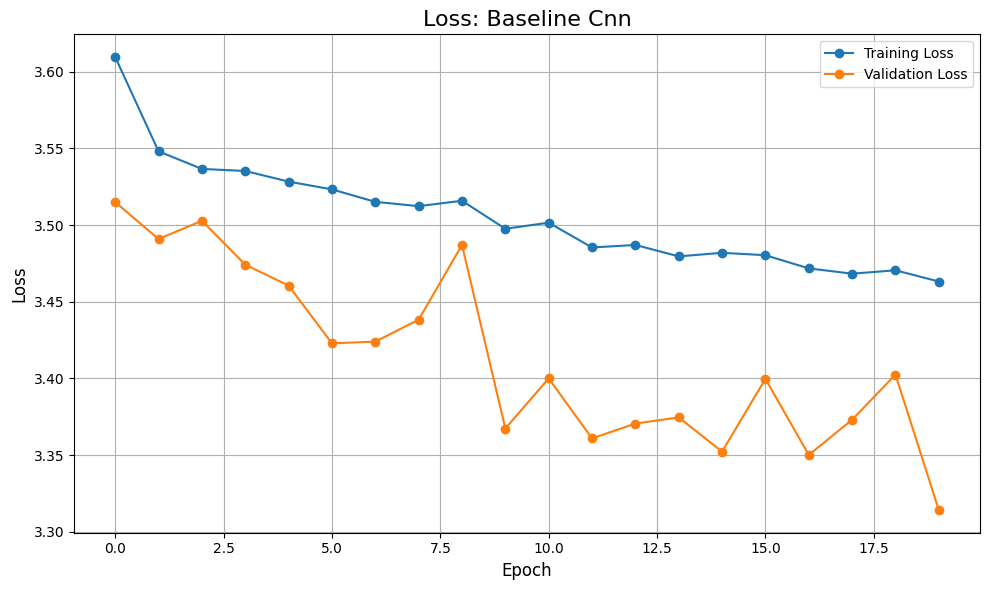

Loss plot saved to /kaggle/working/baseline_cnn/baseline_cnn_loss.png


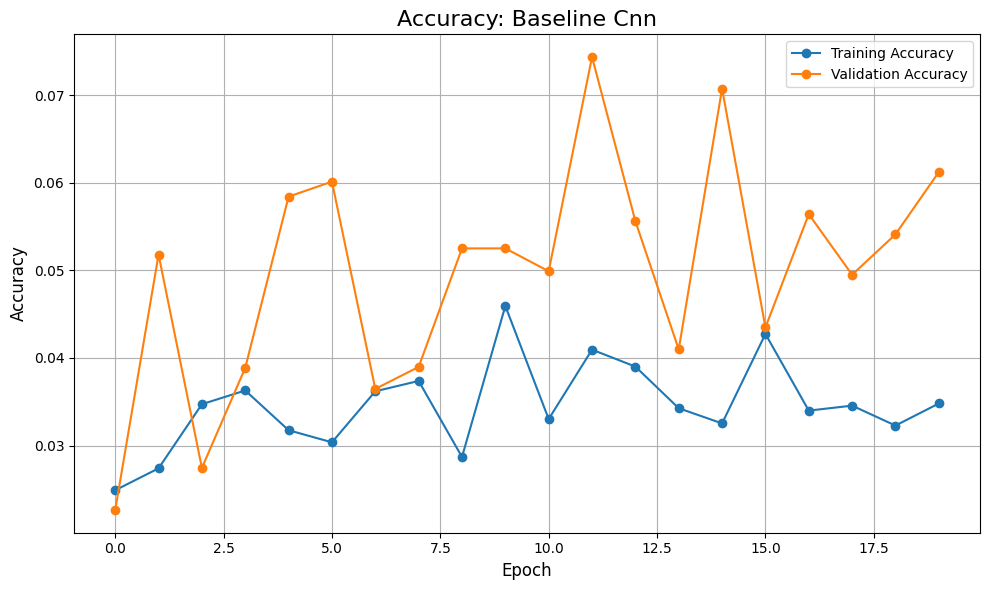

Accuracy plot saved to /kaggle/working/baseline_cnn/baseline_cnn_accuracy.png
Training history saved to /kaggle/working/baseline_cnn/training_history.pkl
Metadata saved to /kaggle/working/baseline_cnn/metadata_baseline_cnn.json

--- Plotting model architecture for: baseline_cnn ---
Model architecture plot saved


/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


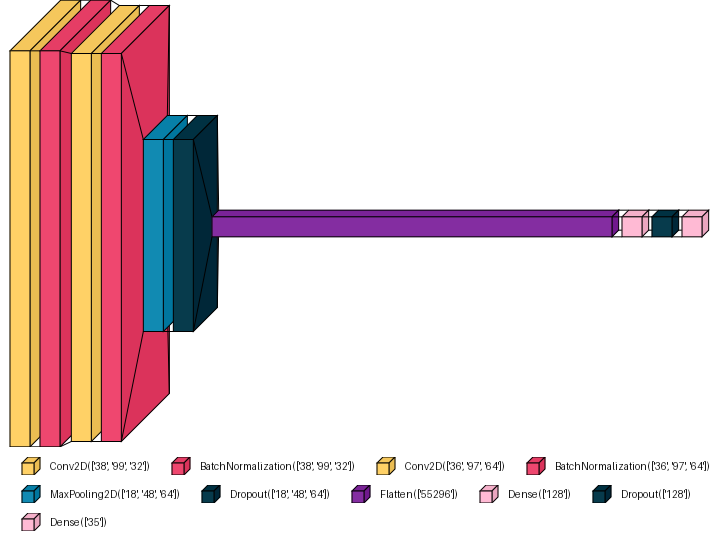

In [19]:
save_and_plot_results(history, model, model_name, saving_dir)

## Residual CNN (ResNet)

#### **Model Purpose and Design Philosophy**

To overcome the potential performance limitations of a shallow network, a Residual CNN (ResNet) was implemented. This architecture is based on the foundational principles of Deep Residual Learning, which enable the training of significantly deeper networks by mitigating the vanishing gradient problem. The goal is to investigate whether a deeper feature hierarchy can capture more intricate and abstract patterns within the log-mel spectrograms, leading to improved classification accuracy compared to the baseline model.

---

#### **Architectural Details**

The model begins with a standard convolutional "stem" layer to perform initial feature extraction, followed by a stack of these residual blocks, and concludes with a classifier head.

* **The Residual Block (`_res_block`):** This is the fundamental building block of the model. Each block contains a "shortcut" or "identity" connection that bypasses two `Conv2D` layers.
    * The main path consists of two (3,3) `Conv2D` layers, with `BatchNormalization` applied after each.
    * The input to the block is added element-wise to the output of the second convolutional layer. This allows the block to learn a *residual function* relative to its input, making it easier for the network to learn identity mappings and enabling smoother gradient flow through greater depth.
    * To handle changes in dimension (either through striding or an increased number of filters), the shortcut connection is projected using a (1,1) `Conv2D` layer to match the output shape of the main path before the addition.

* **Overall Network Structure:** The model employs a stack of three residual blocks.
    1.  The first block operates with 32 filters, preserving the input dimensions.
    2.  The subsequent two blocks progressively downsample the feature maps using a stride of 2 and double the number of filters—first to 64, then to 128. This creates a hierarchical feature pyramid, allowing the model to learn features at multiple scales.

* **Classifier Head:** Instead of a traditional `Flatten` layer, a `GlobalAveragePooling2D` layer is used. This layer averages each feature map into a single value, drastically reducing the number of parameters in the classifier, which helps to prevent overfitting and improve model generalization. A `Dropout` layer with a rate of 0.3 is applied for regularization before the final `softmax` output layer.

---

#### **Advantages and Disadvantages**

* **Advantages:**
    * **Effective Training of Deep Networks:** The core benefit of residual connections is the ability to train much deeper networks effectively, allowing for the learning of more complex and robust feature representations.
    * **Hierarchical Feature Learning:** The progressive downsampling and increase in filter depth across the blocks enable the model to learn a rich hierarchy of spectro-temporal features.
    * **Strong Performance:** As demonstrated by the experimental results, this architecture's capacity for deeper learning translates into state-of-the-art performance for this task.

* **Disadvantages:**
    * **Static Receptive Field:** Although deep, the model is still a pure CNN and processes the spectrogram as a static image. It does not contain an explicit mechanism for modeling long-range temporal relationships, which may be a limitation compared to recurrent or attention-based architectures.

In [20]:
class ResidualCNN:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index)):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()

    def _res_block(self, x, filters, stride=1):
        shortcut = x

        # First convolutional layer
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # Second convolutional layer
        x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)

        # Shortcut connection
        if stride != 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        return x

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)

        x = layers.Conv2D(32, kernel_size=3, strides=1, padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # Residual blocks
        x = self._res_block(x, 32)
        x = self._res_block(x, 64, stride=2)
        x = self._res_block(x, 128, stride=2)

        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        model = models.Model(inputs, outputs)
        return model

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [21]:
residual_cnn = ResidualCNN(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "residual_cnn"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

residual_cnn.compile()

model = residual_cnn.get_model()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.2856 - loss: 2.6431 - val_accuracy: 0.7971 - val_loss: 0.7120 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.7719 - loss: 0.8426 - val_accuracy: 0.8826 - val_loss: 0.4135 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8309 - loss: 0.5949 - val_accuracy: 0.8722 - val_loss: 0.4431 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.8632 - loss: 0.4824 - val_accuracy: 0.8948 - val_loss: 0.3502 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8761 - loss: 0.4271 - val_accuracy: 0.9124 - val_loss: 0.3034 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.8902 - loss: 0.3898 - val_accuracy: 0.9303 - val_loss: 0.2417 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accura

In [22]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 40, 101,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 101,   │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 40, 101,   │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 20, 51,    │     18,496 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 20, 51,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 20, 51,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 20, 51,    │      2,112 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_6[0][0]  

 Total params: 937,259 (3.58 MB)

 Trainable params: 311,971 (1.19 MB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 623,944 (2.38 MB)

In [23]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9534 - loss: 0.1623
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9541 - loss: 0.1619

Validation accuracy: 0.9568
Validation loss: 0.1507

Test accuracy: 0.9523
Test loss: 0.1614



--- Saving results for model: residual_cnn ---


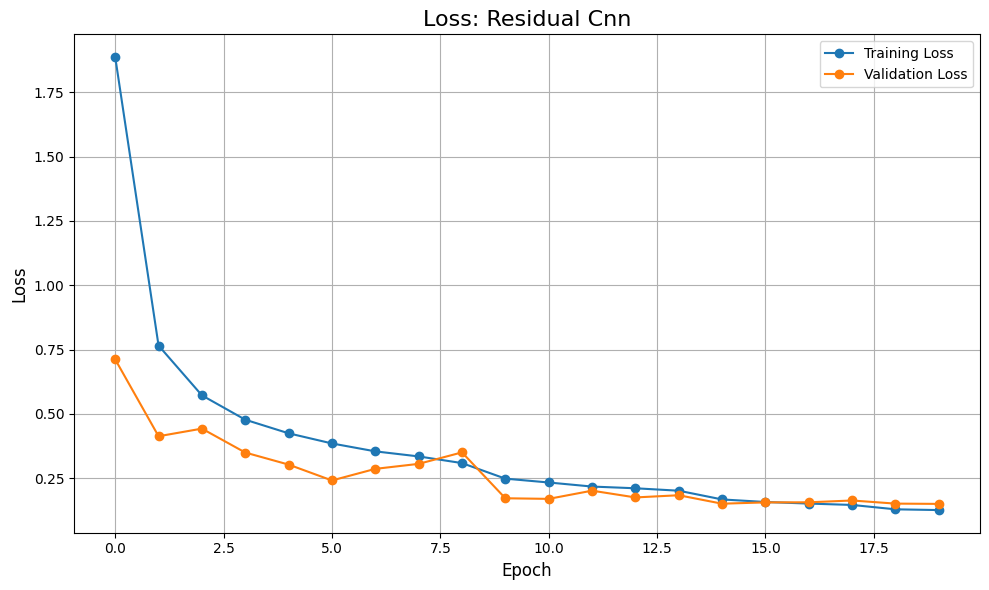

Loss plot saved to /kaggle/working/residual_cnn/residual_cnn_loss.png


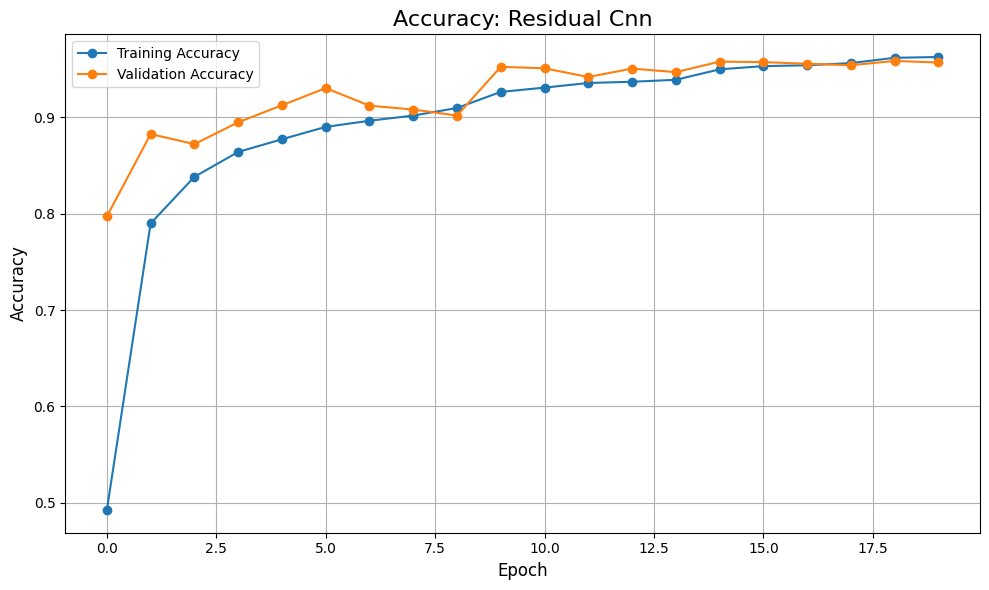

Accuracy plot saved to /kaggle/working/residual_cnn/residual_cnn_accuracy.png
Training history saved to /kaggle/working/residual_cnn/training_history.pkl
Metadata saved to /kaggle/working/residual_cnn/metadata_residual_cnn.json

--- Plotting model architecture for: residual_cnn ---
Model architecture plot saved


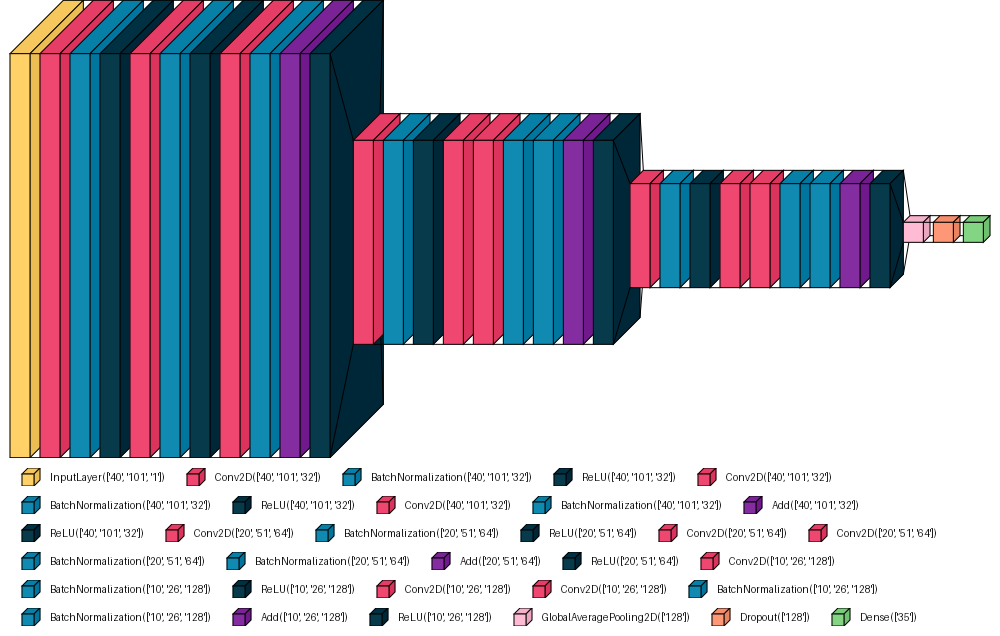

In [24]:
save_and_plot_results(history, model, model_name, saving_dir)

## Hybrid CNN + BiLSTM

#### **Model Purpose and Design Philosophy**

This model was developed to address a potential limitation of pure CNN architectures: the lack of an explicit mechanism for modeling long-range temporal dependencies. The core philosophy is to create a **synergistic hybrid architecture** that leverages the distinct strengths of both Convolutional Neural Networks (CNNs) and Recurrent Neural Networks (RNNs). The design follows a two-stage process aligned with state-of-the-art practices: first, a CNN frontend extracts robust, local spectro-temporal features from the input spectrogram. Second, a Bidirectional Long Short-Term Memory (BiLSTM) backend processes the sequence of these features to model the contextual relationships over time.

---

#### **Architectural Details**

The model is implemented as a pipeline comprising three main stages: a CNN feature extractor, a CNN-to-RNN interface, and a BiLSTM-based classifier.

* **1. CNN Feature Extractor:** The initial stage processes the 40x101 input spectrogram. It consists of two convolutional blocks with **32 and 64 filters**, respectively. Both employ a (3,3) kernel and ReLU activation. Each convolutional layer is followed by `BatchNormalization` for training stability and a `MaxPooling2D` layer for downsampling. This stage produces a compact, high-level feature map of size **10x25x64**.

* **2. CNN-to-RNN Interface:** After feature extraction, the resulting 2D feature map is prepared for the recurrent layer by preserving the original temporal axis of the spectrogram.
    * A `Permute` layer first reorders the dimensions of the feature map to bring the time axis (dimension of 25) to the forefront.
    * A `Reshape` layer then flattens the frequency and channel dimensions, transforming the map into a sequence of **25 time steps**, each with a 640-dimensional feature vector (10 frequencies * 64 channels).
    * A `TimeDistributed(Dense(128))` layer is applied to compress each feature vector from 640 to 128 dimensions, creating a more compact representation for the BiLSTM.

* **3. BiLSTM Modeler and Classifier:** The core of the temporal modeling is a `Bidirectional` wrapper around an `LSTM` layer.
    * The **LSTM** is designed to capture long-term dependencies within the 25-step feature sequence.
    * The **Bidirectional** nature allows the network to process the sequence in both forward and backward directions, enabling each time step's output to be informed by both past and future context.
    * A `GlobalAveragePooling1D` layer aggregates the entire sequence of hidden states from the BiLSTM into a single, fixed-size feature vector.
    * Finally, a classifier head composed of a `Dense` hidden layer and `Dropout` layers processes this vector to produce the final `softmax` probability distribution.

---

#### **Advantages and Disadvantages**

* **Advantages:**
    * **Explicit Temporal Modeling:** By incorporating a BiLSTM, the model is explicitly designed to learn the sequential patterns inherent in speech, which can be critical for distinguishing commands based on their temporal structure.
    * **Hierarchical Feature Processing:** The model benefits from a powerful division of labor: the CNN excels at learning robust, localized features, while the BiLSTM excels at placing these features into a meaningful temporal context.

* **Disadvantages:**
    * **Sequential Computation:** The recurrent nature of the LSTM layer imposes a sequential processing bottleneck, which can result in longer training and inference times compared to fully parallelizable architectures like Transformers.

In [25]:
class CNNBiLSTMModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=12,
                 lstm_units=32, dense_units=64, dropout_rate=0.3):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.lstm_units = lstm_units
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = tf.keras.Input(shape=self.input_shape)

        # CNN Layers
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x) 

        # Reshape
        x = layers.Permute((2, 1, 3))(x)
        current_shape = x.shape
        x = layers.Reshape((current_shape[1], current_shape[2] * current_shape[3]))(x)

        # Feature Compression
        x = layers.TimeDistributed(layers.Dense(128, activation='relu'))(x)

        # BiLSTM with return_sequences
        x = layers.Bidirectional(
            layers.LSTM(self.lstm_units, return_sequences=True)
        )(x)

        # Pooling across time
        x = layers.GlobalAveragePooling1D()(x)

        # Dropout + Classifier
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(self.dense_units, activation='relu')(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        return models.Model(inputs, outputs)

    def compile(self, learning_rate=0.001):
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

    def get_model(self):
        return self.model

In [26]:
cnn_bilstm = CNNBiLSTMModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "cnn_bilstm"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

cnn_bilstm.compile()

model = cnn_bilstm.get_model()

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.2703 - loss: 2.6145 - val_accuracy: 0.8114 - val_loss: 0.6716 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.7248 - loss: 0.9380 - val_accuracy: 0.8771 - val_loss: 0.4435 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.8126 - loss: 0.6458 - val_accuracy: 0.9132 - val_loss: 0.3061 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.8463 - loss: 0.5344 - val_accuracy: 0.9205 - val_loss: 0.2754 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.8691 - loss: 0.4604 - val_accuracy: 0.9307 - val_loss: 0.2369 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.8803 - loss: 0.4159 - val_accuracy: 0.9241 - val_loss: 0.2550 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accura

In [27]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 40, 101, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 40, 101, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 20, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 20, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 25, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 25, 640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 25, 128)        │        82,048 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 25, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,315 (1.70 MB)

 Trainable params: 148,707 (580.89 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 297,416 (1.13 MB)

In [28]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9458 - loss: 0.2136
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9475 - loss: 0.1924

Validation accuracy: 0.9475
Validation loss: 0.1965

Test accuracy: 0.9441
Test loss: 0.1918



--- Saving results for model: cnn_bilstm ---


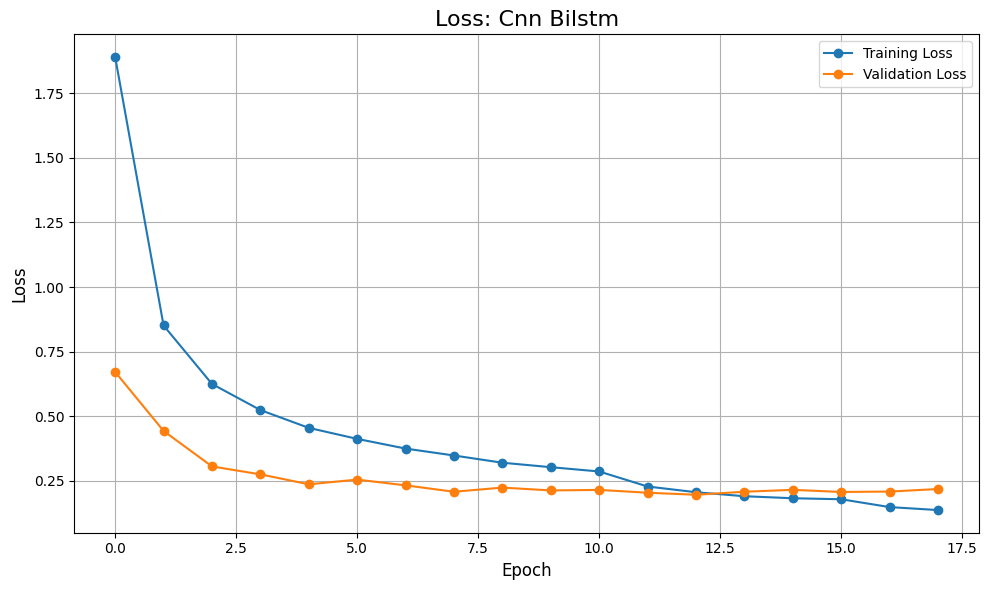

Loss plot saved to /kaggle/working/cnn_bilstm/cnn_bilstm_loss.png


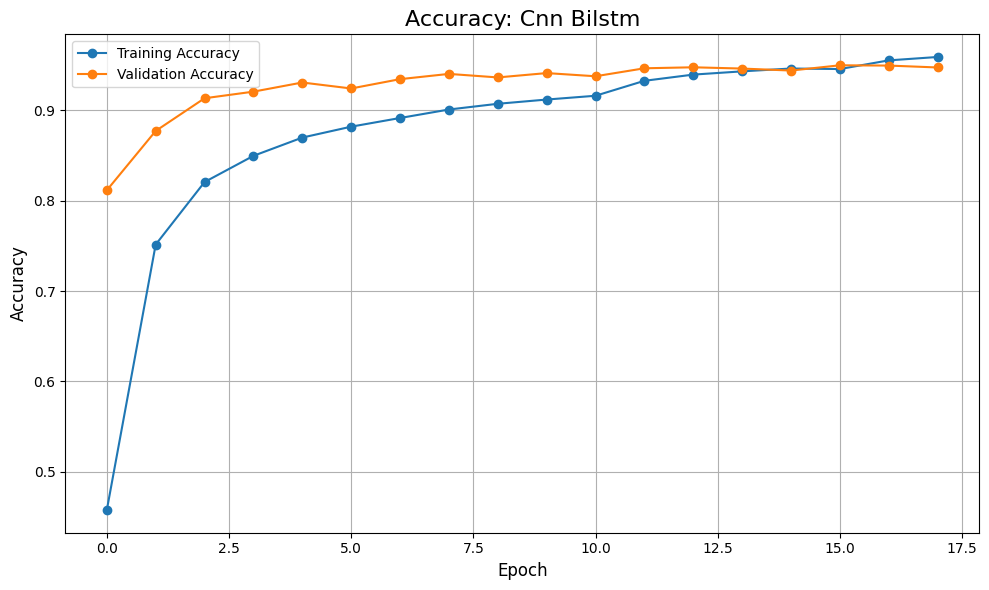

Accuracy plot saved to /kaggle/working/cnn_bilstm/cnn_bilstm_accuracy.png
Training history saved to /kaggle/working/cnn_bilstm/training_history.pkl
Metadata saved to /kaggle/working/cnn_bilstm/metadata_cnn_bilstm.json

--- Plotting model architecture for: cnn_bilstm ---
Model architecture plot saved


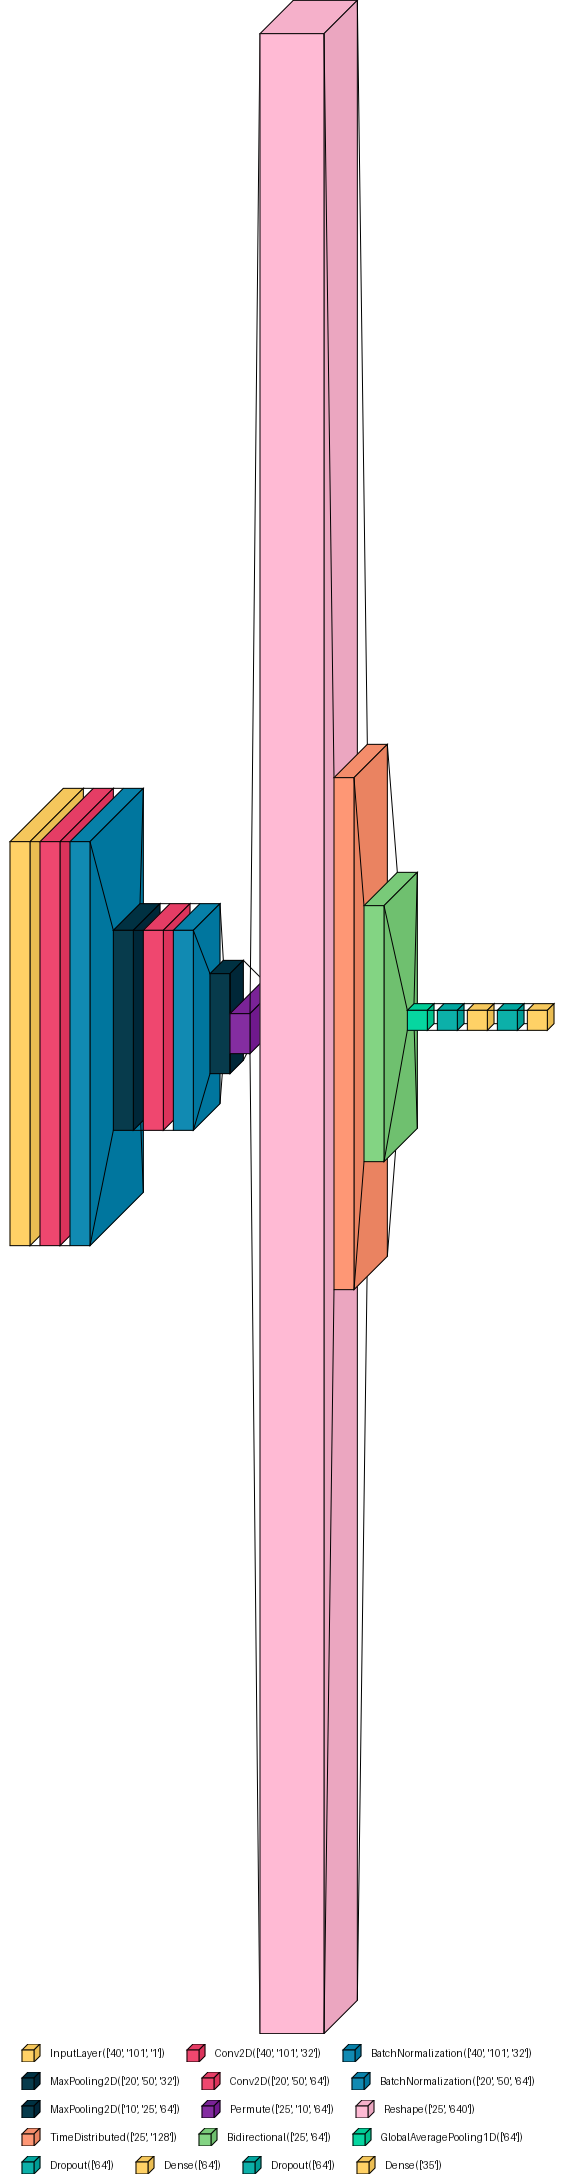

In [29]:
save_and_plot_results(history, model, model_name, saving_dir)

## Hybrid CNN + Transformer

#### **Model Purpose and Design Philosophy**

This hybrid architecture was developed to explore a more modern approach to sequence modeling, replacing the recurrent layers of the CNN-BiLSTM model with a Transformer-based encoder. The core design philosophy remains a two-stage process: a CNN frontend extracts local spectro-temporal features, and a powerful backend then models the relationships between these features. By using a Transformer encoder, this model aims to leverage the self-attention mechanism to capture global, long-range dependencies across the entire utterance in a highly parallelizable manner, potentially offering a more powerful alternative to sequential RNNs.

---

#### **Architectural Details**

The model's pipeline is composed of a CNN feature extractor, a feature sequencing and embedding stage, and a Transformer encoder backend for classification.

* **1. CNN Feature Extractor:** This stage is identical to the frontend of the CNN-BiLSTM model. It employs two convolutional blocks (with 16 and 32 filters, respectively), each containing a `Conv2D` layer, `BatchNormalization`, and `MaxPooling2D`. This efficiently produces a downsampled 2D feature map that represents local acoustic patterns.

* **2. Feature Sequencing and Embedding:** This crucial stage bridges the convolutional and attention-based components.
    * First, a `Permute` layer reorders the dimensions of the CNN output to bring the time axis to the forefront, preparing it for sequential processing.
    * Next, a `Reshape` layer flattens the frequency and channel dimensions into a single feature vector for each time step, effectively converting the 2D feature map into a 1D sequence.
    * A `Dense` layer then projects this high-dimensional feature vector into the Transformer's lower-dimensional embedding space (`embed_dim`).
    * Finally, a `PositionalEncoding` layer is added to the sequence. This is essential, as the self-attention mechanism is permutation-invariant. This layer injects information about the absolute position of each time step into the embeddings, allowing the model to understand sequence order.

* **3. Transformer Encoder Backend:** The core of this model is a stack of two standard Transformer encoder blocks. Each block consists of two main sub-layers:
    * A **Multi-Head Self-Attention** layer, which allows the model to weigh the importance of all other time steps in the sequence when encoding a specific time step. This enables the model to capture global contextual relationships.
    * A position-wise **Feed-Forward Network**, which applies a non-linear transformation to each time step's representation.
    * Both sub-layers employ residual connections and `LayerNormalization` to ensure stable training of the deep architecture.
    * I tried also to replace the LayerNormalization layer with a Dynamic Tanh following the [Transformers without Normalization paper](https://arxiv.org/abs/2503.10622v2) but even if the inference time was reduced the accuracy and F1 score decreased.

* **4. Classifier Head:** The sequence of outputs from the final Transformer block is aggregated into a single vector using `GlobalAveragePooling1D`. This vector is then passed through a small multi-layer perceptron with `Dropout` for regularization, terminating in a `softmax` layer for final class probability prediction.

---

#### **Advantages and Disadvantages**

* **Advantages:**
    * **Global Context Modeling:** The self-attention mechanism is theoretically capable of modeling dependencies between any two points in the sequence, regardless of their distance, making it extremely powerful for capturing global context.
    * **Parallelization:** Unlike sequential RNNs, the computations within the Transformer's self-attention and feed-forward layers are highly parallelizable, which can lead to significantly faster training on modern GPUs.
    * **State-of-the-Art Foundation:** The architecture is based on the Transformer model, which is the current state-of-the-art in numerous sequence modeling tasks.

* **Disadvantages:**
    * **Data and Computationally Intensive:** Transformers are known to be data-hungry. The quadratic complexity of self-attention with respect to sequence length also makes them computationally expensive, which may not be ideal for resource-constrained environments.
    * **Weaker Inductive Bias:** The model relies on the CNN frontend to provide a strong inductive bias for local patterns. However, the Transformer component itself is less biased towards locality, which can make it more challenging to train on smaller datasets compared to pure CNN or RNN models.

In [30]:
def transformer_encoder_block(embed_dim, num_heads, ff_dim, dropout_rate=0.1):
    inputs = layers.Input(shape=(None, embed_dim))
    
    # Multi-Head Attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim
    )(inputs, inputs)
    attention_output = layers.Dropout(dropout_rate)(attention_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    # Feed-Forward Network
    ffn_output = layers.Dense(ff_dim, activation="relu")(out1)
    ffn_output = layers.Dense(embed_dim)(ffn_output)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    
    return models.Model(inputs=inputs, outputs=out2)

@register_keras_serializable()
class PositionalEncoding(layers.Layer):
    def __init__(self, max_steps, max_dims, **kwargs):
        super().__init__(**kwargs)
        self.max_steps = max_steps
        self.max_dims = max_dims
        self.positional_encoding = self.build_pe(max_steps, max_dims)

    def build_pe(self, max_steps, max_dims):
        pe = np.zeros((max_steps, max_dims))
        position = np.arange(0, max_steps, dtype=np.float32).reshape(-1, 1)
        div_term = np.exp(np.arange(0, max_dims, 2, dtype=np.float32) * -(np.log(10000.0) / max_dims))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        return tf.constant(pe, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.positional_encoding

    def get_config(self):
        config = super().get_config()
        config.update({
            "max_steps": self.max_steps,
            "max_dims": self.max_dims,
        })
        return config

In [31]:
class HybridCNNTransformerModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index),
                 num_transformer_blocks=2, embed_dim=64, num_heads=4, ff_dim=64, dropout_rate=0.2):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.num_transformer_blocks = num_transformer_blocks
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)

        # Convolutional Feature Extractor
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        # Reshape to a sequence
        x = layers.Permute((2, 1, 3))(x)

        x = layers.Reshape((x.shape[1], -1))(x)
        
        # Project to the Transformer's embedding dimension
        x = layers.Dense(self.embed_dim)(x)
        
        # Add Positional Encoding
        x = PositionalEncoding(max_steps=x.shape[1], max_dims=self.embed_dim)(x)

        # Transformer Encoder Blocks
        for _ in range(self.num_transformer_blocks):
            encoder = transformer_encoder_block(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
            x = encoder(x)
        
        # Classifier Head
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(self.ff_dim, activation='relu')(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        return models.Model(inputs=inputs, outputs=outputs)

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [32]:
hybrid_cnn_transformer = HybridCNNTransformerModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "hybrid_cnn_transformer"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

hybrid_cnn_transformer.compile()

model = hybrid_cnn_transformer.get_model()

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.3342 - loss: 2.3459 - val_accuracy: 0.8346 - val_loss: 0.5530 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7521 - loss: 0.8525 - val_accuracy: 0.8540 - val_loss: 0.5038 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7897 - loss: 0.7258 - val_accuracy: 0.8631 - val_loss: 0.4482 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8153 - loss: 0.6407 - val_accuracy: 0.8620 - val_loss: 0.4707 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8231 - loss: 0.6237 - val_accuracy: 0.8699 - val_loss: 0.4429 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8148 - loss: 0.6450 - val_accuracy: 0.9001 - val_loss: 0.3454 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.

In [33]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 40, 101, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 40, 101, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 20, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 20, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_1 (Permute)             │ (None, 25, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 25, 640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 25, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_3 (Functional)       │ (None, 25, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_4 (Functional)       │ (None, 25, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,259 (2.48 MB)

 Trainable params: 216,355 (845.14 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 432,712 (1.65 MB)

In [34]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9368 - loss: 0.2196
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9376 - loss: 0.2261

Validation accuracy: 0.9362
Validation loss: 0.2266

Test accuracy: 0.9339
Test loss: 0.2343



--- Saving results for model: hybrid_cnn_transformer ---


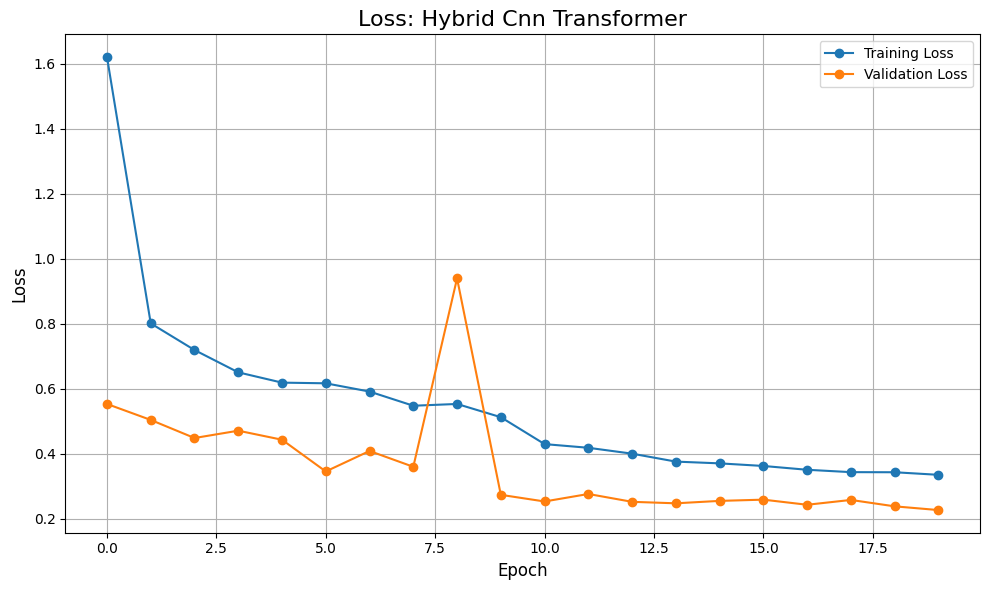

Loss plot saved to /kaggle/working/hybrid_cnn_transformer/hybrid_cnn_transformer_loss.png


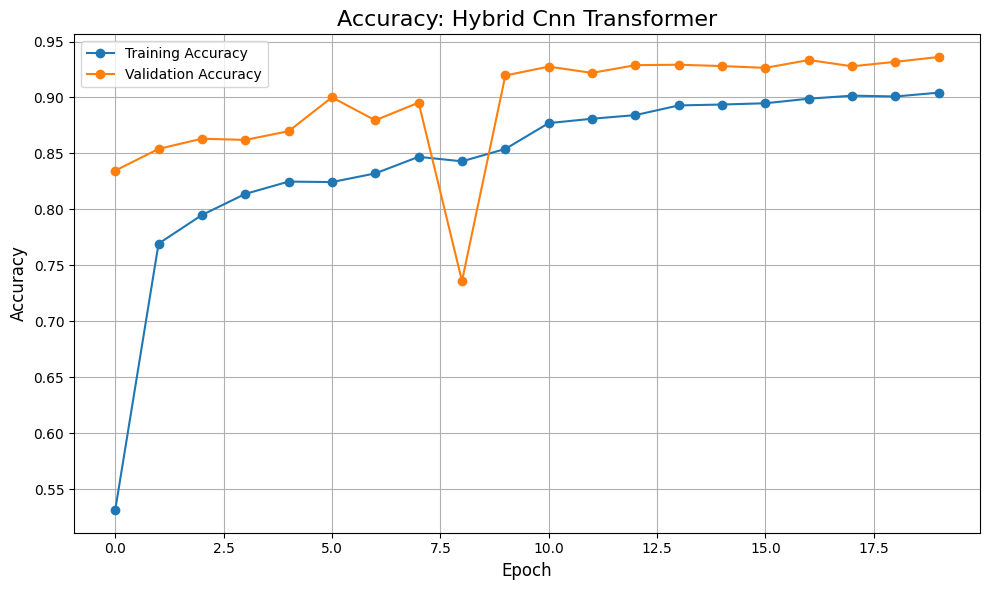

Accuracy plot saved to /kaggle/working/hybrid_cnn_transformer/hybrid_cnn_transformer_accuracy.png
Training history saved to /kaggle/working/hybrid_cnn_transformer/training_history.pkl
Metadata saved to /kaggle/working/hybrid_cnn_transformer/metadata_hybrid_cnn_transformer.json


In [35]:
save_and_plot_results(history, model, model_name, saving_dir, transformer = True)

## Vision Transformer (ViT)

#### **Model Purpose and Design Philosophy**

The Vision Transformer (ViT) model represents a paradigm shift from the convolutional architectures previously explored. Directly inspired by the success of Transformers in natural language processing and their subsequent application to computer vision, this model abandons the inductive biases of CNNs entirely. The core philosophy is to treat the 2D log-mel spectrogram not as a grid of pixels, but as a **sequence of smaller image patches**. The objective is to determine if a pure, self-attention-based architecture can effectively learn the complex spectro-temporal patterns for keyword spotting without relying on convolutional feature extraction.

---

#### **Architectural Details**

The ViT architecture is implemented as a pipeline that first converts the input image into a sequence of embeddings and then processes this sequence with a standard Transformer encoder.

* **1. Spectrogram-to-Patch Transformation:** The input spectrogram (40x101) is first resized to a compatible dimension (40x104) to ensure it can be evenly divided. A custom `Patches` layer then partitions this spectrogram into a grid of non-overlapping patches of a fixed size (e.g., 8x8). These patches are subsequently flattened, converting the 2D image into a 1D sequence of patch vectors, which is the standard input format for a Transformer.

* **2. Patch and Position Embedding:** A custom `PatchEncoder` layer is responsible for converting the raw patch vectors into enriched embeddings suitable for the Transformer. This process has two key steps:
    * **Linear Projection:** A trainable `Dense` layer projects each flattened patch into the Transformer's latent embedding space (`embed_dim`). This is a critical step that allows the model to learn a meaningful representation for each patch.
    * **Learnable Positional Embeddings:** Since the self-attention mechanism is permutation-invariant, positional information must be explicitly injected. This model uses learnable positional embeddings, where a unique vector is learned for each patch position and added to the corresponding patch embedding. This provides the model with crucial spatial awareness.

* **3. Transformer Encoder:** The resulting sequence of patch embeddings is processed by a stack of two standard `transformer_encoder_block`s. As in the hybrid model, each block uses `MultiHeadAttention` to weigh the importance of all other patches when encoding a specific patch. This allows the model to capture global relationships and context across the entire spectrogram from the very first layer.

* **4. Classifier Head:** To produce a final classification, the sequence of output embeddings from the Transformer encoder is aggregated into a single feature vector using a `GlobalAveragePooling1D` layer. This vector is then passed through a small Multi-Layer Perceptron (MLP) head, consistent with our other Transformer-based model. This head consists of a `Dense` hidden layer with ReLU activation, followed by `Dropout` for regularization, before terminating in a final `softmax` layer for class probability prediction.

---

#### **Advantages and Disadvantages**

* **Advantages:**
    * **Global Receptive Field:** From the very first layer, self-attention can model relationships between any pair of patches, no matter how distant. This provides a truly global receptive field, which is theoretically powerful for capturing long-range spectro-temporal dependencies.
    * **Scalability:** ViT architectures have demonstrated excellent scalability. Their performance can consistently improve with more data and larger model sizes, making them suitable for very large-scale tasks.
    * **Architectural Simplicity:** The model uses a uniform architecture (the Transformer block) repeated multiple times.

* **Disadvantages:**
    * **Lack of Inductive Bias:** This is the most significant drawback. By discarding convolutions, the model loses the built-in assumption of locality and translation invariance. This makes ViTs less data-efficient than CNNs, often requiring massive datasets or extensive pre-training to learn these fundamental properties from scratch.
    * **High Computational Cost:** The self-attention mechanism has a computational and memory complexity that is quadratic with respect to the number of patches. This can make ViTs very demanding for high-resolution inputs, which would result in long sequences.

In [36]:
@register_keras_serializable()
class Patches(layers.Layer):
    """Splits an image into patches."""
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches
    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config
    

@register_keras_serializable()
class PatchEncoder(layers.Layer):
    """Encodes patches with a projection and positional embedding."""
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim
        
    def build(self, input_shape):
        self.projection = layers.Dense(units=self.embed_dim)
        self.positional_embedding = layers.Embedding(
            input_dim=self.num_patches, output_dim=self.embed_dim
        )
        super().build(input_shape)

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.positional_embedding(positions)
        return encoded
        
    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "embed_dim": self.embed_dim,
        })
        return config

In [37]:
class VisionTransformerModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index),
                 patch_size=8, num_transformer_blocks=2, embed_dim=64, 
                 num_heads=4, ff_dim=64, dropout_rate=0.2):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.patch_size = patch_size
        self.num_transformer_blocks = num_transformer_blocks
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)
        
        # Since the input dimensions (40, 101) are not perfectly divisible by patch_size,
        # we first resize to a divisible dimension, e.g., (40, 104) -> divisible by 8
        # Note: 101 is prime, so padding/resizing is needed. I choose 104 as new size.
        resized_input = layers.Resizing(height=40, width=104)(inputs)
        
        # Create Patches
        num_patches = (40 // self.patch_size) * (104 // self.patch_size)
        patches = Patches(self.patch_size)(resized_input)

        # Encode Patches with positional embedding
        encoded_patches = PatchEncoder(num_patches, self.embed_dim)(patches)

        # Transformer Encoder Blocks
        x = encoded_patches
        for _ in range(self.num_transformer_blocks):
            encoder = transformer_encoder_block(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
            x = encoder(x)
            
        # Classifier Head
        # Global average pooling over the sequence of patches
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(self.ff_dim, activation='relu')(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(self.num_classes, activation="softmax")(x)

        return models.Model(inputs=inputs, outputs=outputs)
    
    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [38]:
vision_transformer = VisionTransformerModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "vision_transformer"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

vision_transformer.compile()

model = vision_transformer.get_model()

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - accuracy: 0.0727 - loss: 3.3800 - val_accuracy: 0.3728 - val_loss: 2.0993 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3170 - loss: 2.3425 - val_accuracy: 0.5420 - val_loss: 1.4996 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4867 - loss: 1.7659 - val_accuracy: 0.6817 - val_loss: 1.0428 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5667 - loss: 1.4796 - val_accuracy: 0.7305 - val_loss: 0.8590 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6063 - loss: 1.3279 - val_accuracy: 0.7577 - val_loss: 0.8052 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6395 - loss: 1.2112 - val_accuracy: 0.7757 - val_loss: 0.7275 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6

In [39]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 40, 104, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patches (Patches)               │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_encoder (PatchEncoder)    │ (None, 65, 64)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_6 (Functional)       │ (None, 65, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_7 (Functional)       │ (None, 65, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493,931 (1.88 MB)

 Trainable params: 164,643 (643.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 329,288 (1.26 MB)

In [40]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8641 - loss: 0.4487
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8474 - loss: 0.4986

Validation accuracy: 0.8658
Validation loss: 0.4450

Test accuracy: 0.8493
Test loss: 0.4925



--- Saving results for model: vision_transformer ---


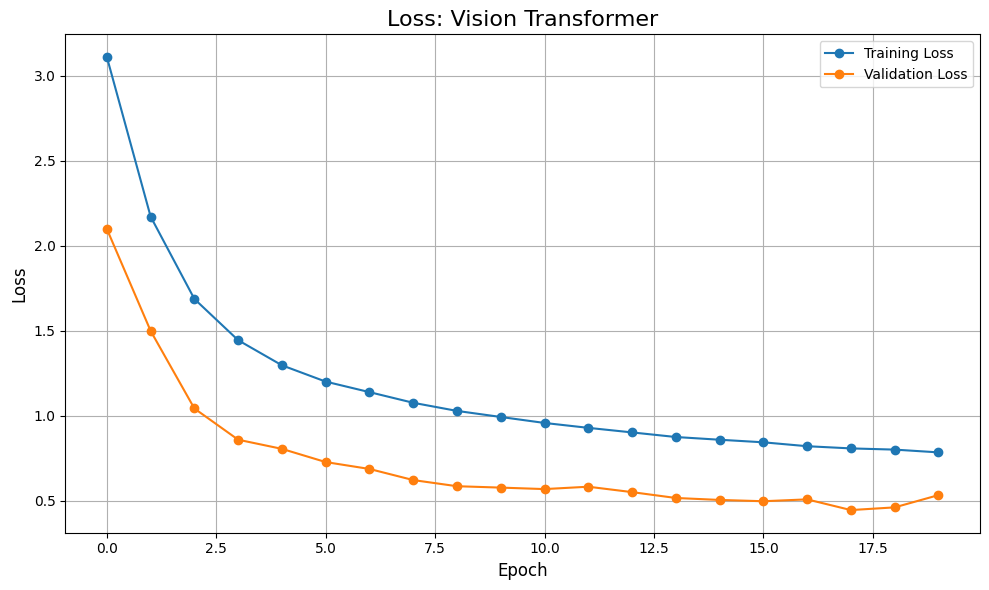

Loss plot saved to /kaggle/working/vision_transformer/vision_transformer_loss.png


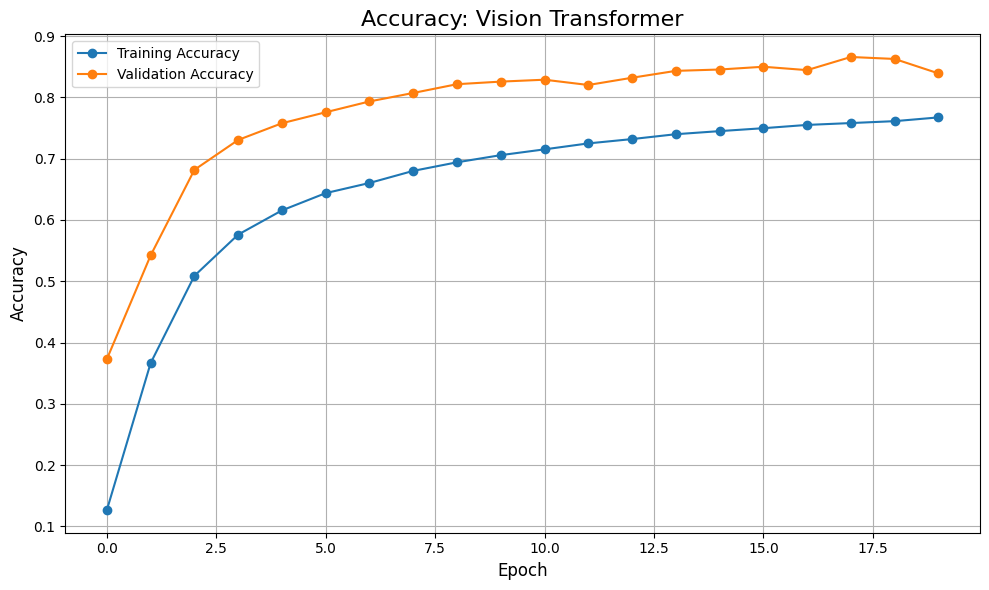

Accuracy plot saved to /kaggle/working/vision_transformer/vision_transformer_accuracy.png
Training history saved to /kaggle/working/vision_transformer/training_history.pkl
Metadata saved to /kaggle/working/vision_transformer/metadata_vision_transformer.json


In [41]:
save_and_plot_results(history, model, model_name, saving_dir, transformer = True)

## Experimental model

### **GAN-Inspired Residual Network with Channel-wise Attention**

#### **Model Purpose and Design Philosophy**

This model represents a novel, experimental architecture developed to explore whether concepts from different deep learning domains could be synthesized to push the performance boundary for keyword spotting. The design philosophy is to augment a powerful feature extractor with advanced mechanisms for feature refinement and classification.

The architecture integrates three key ideas:
1.  A **ResNet backbone** for robust, hierarchical feature extraction.
2.  A **Squeeze-and-Excitation (SE)** block for dynamic, channel-wise feature recalibration.
3.  A **classifier whose architecture is inspired by GAN discriminators**, designed to learn a highly robust decision function.

The objective is to create a model that not only learns powerful features but also learns to focus on the most informative among them.

---

#### **Architectural Details**

The model is structured as a three-stage pipeline: a ResNet feature extractor, a channel-wise attention module, and a GAN-inspired classifier head.

* **1. ResNet Feature Extractor:** The model's frontend is identical to the `ResidualCNN` architecture described previously. It leverages a stem and a stack of three residual blocks to process the input spectrogram and generate a high-level feature map. This provides a strong foundation of rich, multi-scale features.

* **2. Squeeze-and-Excitation (SE) Attention Block:** After the ResNet backbone, a Squeeze-and-Excitation block is inserted to perform channel-wise attention. This block adaptively recalibrates the feature map by explicitly modeling the interdependencies between channels.
    * **Squeeze:** First, `GlobalAveragePooling2D` is used to squeeze the global spatial information of the feature map into a single channel descriptor vector.
    * **Excite:** This vector is then fed through a small two-layer `Dense` network, which acts as a bottleneck. This network learns to model non-linear channel relationships and outputs a set of attention weights (one for each channel) using a `sigmoid` activation.
    * **Rescale:** The original feature map from the ResNet backbone is then multiplied channel-wise by these attention weights. This step dynamically amplifies the most relevant feature channels for the given input while suppressing less useful ones.

* **3. GAN-Inspired Classifier:** The final stage is a classifier whose design cues are taken from modern GAN discriminators, which are architected to be powerful feature classifiers.
    * It uses a stack of strided `Conv2D` layers to aggressively downsample the feature map, a common pattern in discriminator networks.
    * Crucially, it employs **`LeakyReLU`** as its activation function. Unlike standard ReLU, `LeakyReLU` allows a small, non-zero gradient when the unit is not active, which is a technique often used in GANs to ensure more stable gradient flow.
    * Strong regularization is applied through both `L2` weight decay and `Dropout` to enhance generalization.
    * The classification concludes with a `GlobalAveragePooling2D` layer and a final `softmax` output layer.

---

#### **Advantages and Disadvantages**

* **Advantages:**
    * **Dynamic Feature Recalibration:** The primary advantage is the SE block, which gives the model the ability to dynamically weigh the importance of its learned feature channels based on the input, leading to a more refined and focused representation.
    * **Novelty and Originality:** The architecture is a unique synthesis of concepts from classification (ResNet), attention mechanisms (SE), and generative models (GANs), demonstrating a highly creative and experimental approach to model design.
    * **State-of-the-Art Performance:** As validated by the results, this novel combination of techniques proved to be extremely effective, achieving top-tier performance on the task.

* **Disadvantages:**
    * **Increased Complexity:** The addition of the SE block and a more complex classifier head increases the model's parameter count and architectural complexity compared to a standard ResNet.
    * **Non-Standard Design:** While effective, the use of GAN-inspired components for a classification task is unconventional and requires careful fine-tuning.

In [42]:
def squeeze_excite_block(input_tensor, ratio=8):
    """Squeeze-and-Excitation block"""
    init = input_tensor
    channel_axis = -1
    filters = init.shape[channel_axis]
    se_shape = (1, 1, filters)

    se = layers.GlobalAveragePooling2D()(init)
    se = layers.Reshape(se_shape)(se)
    se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)

    x = layers.multiply([init, se])
    return x

In [43]:
class ResidualGAN:
    def __init__(self, input_shape=(40, 101, 1), num_classes=label_to_index,
                 dropout_rate=0.4):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _res_block(self, x, filters, stride=1):
        """ Same residual block as the Residual CNN Model"""
        shortcut = x
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)
        if stride != 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        return x

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)
        l2_rate = 1e-4

        # Feature Extractor (based on Residual CNN)
        x = layers.Conv2D(32, kernel_size=3, strides=1, padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        
        x = self._res_block(x, 32)
        x = self._res_block(x, 64, stride=2)
        feature_map = self._res_block(x, 128, stride=2)

        # Attention Block
        attention_map = squeeze_excite_block(feature_map)

        # Discriminator-style Classifier
        x = layers.Conv2D(128, kernel_size=3, strides=2, padding='same',
                          kernel_regularizer=regularizers.l2(l2_rate))(attention_map)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        x = layers.Dropout(self.dropout_rate)(x)

        x = layers.Conv2D(256, kernel_size=3, strides=2, padding='same',
                          kernel_regularizer=regularizers.l2(l2_rate))(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        x = layers.Dropout(self.dropout_rate)(x)

        x = layers.GlobalAveragePooling2D()(x)
        
        outputs = layers.Dense(self.num_classes, activation='softmax',
                               kernel_regularizer=regularizers.l2(l2_rate))(x)

        return models.Model(inputs=inputs, outputs=outputs)

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [44]:
residual_attention_gan = ResidualGAN(input_shape=(40, 101, 1), num_classes=len(label_to_index))

model_name = "residual_attention_gan"
saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
os.makedirs(saving_dir, exist_ok=True)

residual_attention_gan.compile()

model = residual_attention_gan.get_model()

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(saving_dir, f"{model_name}_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

lr_scheduler_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_cb, checkpoint_cb, lr_scheduler_cb]
)

Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.4885 - loss: 1.8298 - val_accuracy: 0.8507 - val_loss: 0.5756 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.8515 - loss: 0.5780 - val_accuracy: 0.9150 - val_loss: 0.3684 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.8847 - loss: 0.4815 - val_accuracy: 0.9337 - val_loss: 0.3184 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.9037 - loss: 0.4201 - val_accuracy: 0.9326 - val_loss: 0.3192 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.9156 - loss: 0.3815 - val_accuracy: 0.9435 - val_loss: 0.2971 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.9220 - loss: 0.3661 - val_accuracy: 0.9193 - val_loss: 0.3714 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accura

In [45]:
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 40, 101,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 40, 101,   │        320 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 40, 101,   │      9,248 │ re_lu_7[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 40, 101,   │      9,248 │ re_lu_8[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 40, 101,   │          0 │ add_11[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 20, 51,    │     18,496 │ re_lu_9[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 20, 51,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 20, 51,    │     36,928 │ re_lu_10[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 20, 51,    │      2,112 │ re_lu_9[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_19[0][0] 

 Total params: 2,291,243 (8.74 MB)

 Trainable params: 763,299 (2.91 MB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 1,526,600 (5.82 MB)

In [46]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9542 - loss: 0.2399
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9539 - loss: 0.2371

Validation accuracy: 0.9564
Validation loss: 0.2361

Test accuracy: 0.9542
Test loss: 0.2394



--- Saving results for model: residual_attention_gan ---


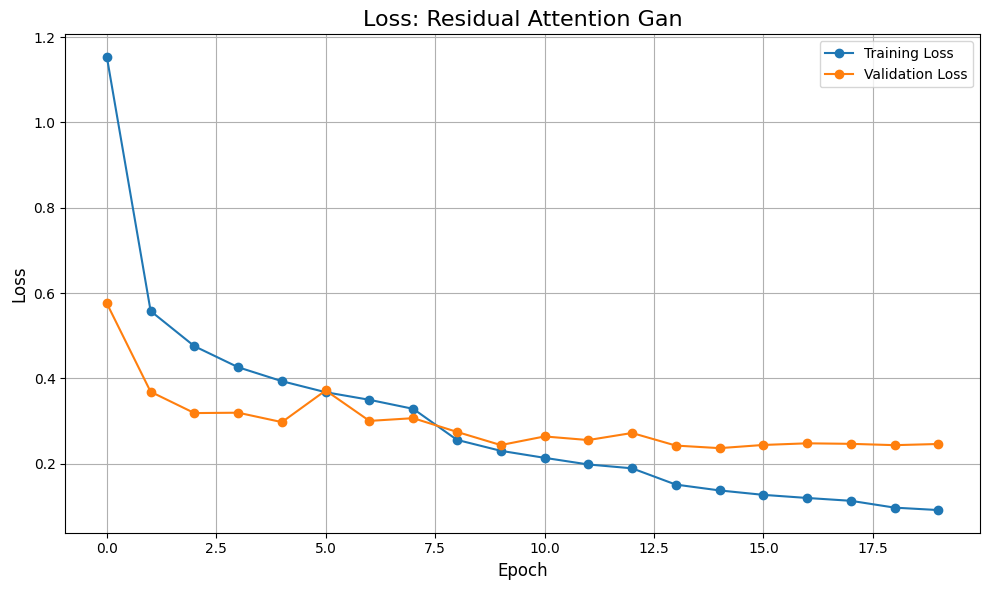

Loss plot saved to /kaggle/working/residual_attention_gan/residual_attention_gan_loss.png


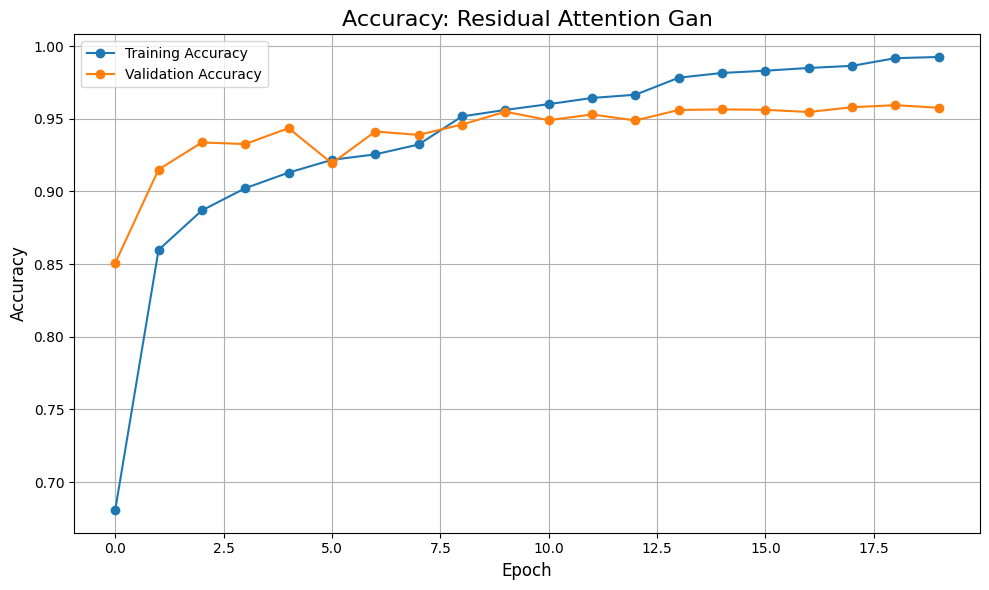

Accuracy plot saved to /kaggle/working/residual_attention_gan/residual_attention_gan_accuracy.png
Training history saved to /kaggle/working/residual_attention_gan/training_history.pkl
Metadata saved to /kaggle/working/residual_attention_gan/metadata_residual_attention_gan.json

--- Plotting model architecture for: residual_attention_gan ---
Model architecture plot saved


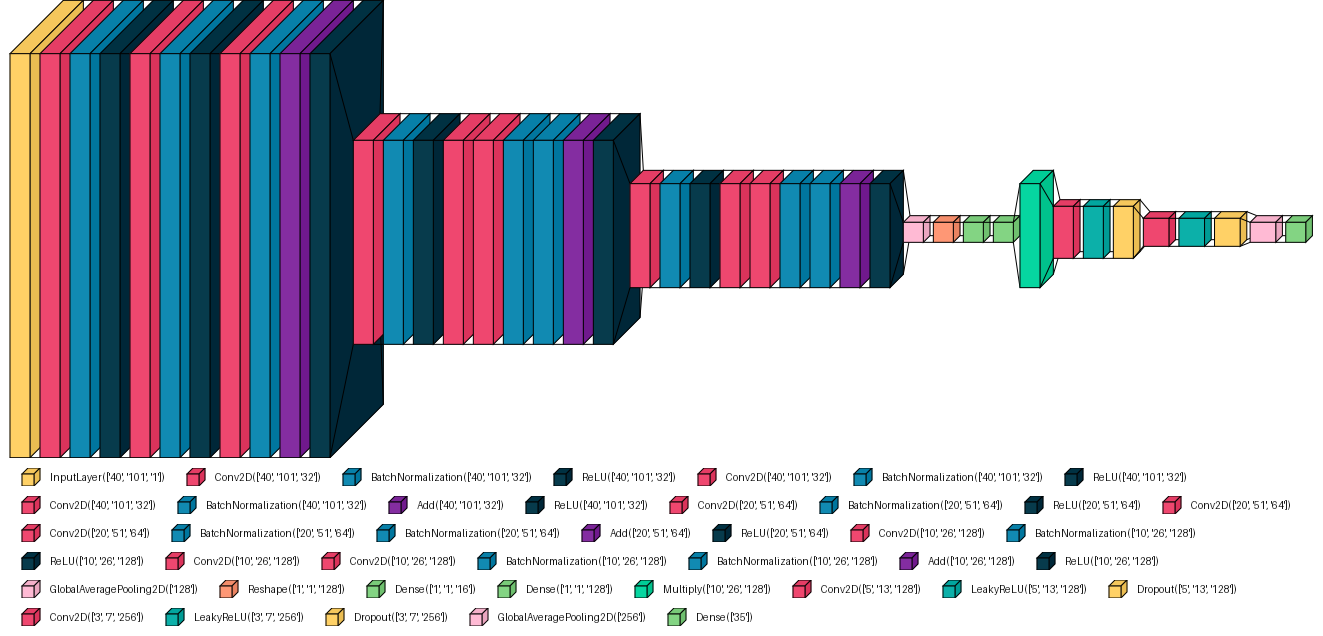

In [47]:
save_and_plot_results(history, model, model_name, saving_dir)

# Models Evaluation

In [48]:
class ModelEvaluator:
    def __init__(self, models_dir, test_data, test_labels, index_to_label, custom_objects=None, output_dir="output"):
        self.models_dir = models_dir
        self.X_test, self.y_test = test_data, test_labels
        self.index_to_label = index_to_label
        self.custom_objects = custom_objects
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        self.results = []
        self.df_results = None

    def _measure_inference_time(self, model, num_runs=10):
        """Evaluate the inference time of a model"""
        dummy_input = self.X_test[:1]
        
        # Dummy execution to startup the model
        _ = model.predict(dummy_input, verbose=0)
        
        start_time = time.time()
        for _ in range(num_runs):
            _ = model.predict(self.X_test, verbose=0, batch_size=64)
        end_time = time.time()
        
        avg_time_per_sample_ms = ((end_time - start_time) / num_runs / len(self.X_test)) * 1000
        return avg_time_per_sample_ms

    def _calculate_multiclass_auc(self, y_true, y_pred_proba, all_classes):
        """Computes AUC for the multi-class problem using OvR"""
        y_true_binarized = label_binarize(y_true, classes=all_classes)
        return roc_auc_score(y_true_binarized, y_pred_proba, multi_class='ovr', average='macro')

    def plot_tsne_embeddings(self, model, model_name):
        print(f"\n--- Generating T-SNE plot for {model_name} ---")
        
        # Creates a model to exctarc the features embeddings
        feature_extractor = models.Model(
            inputs=model.input,
            outputs=model.layers[-2].output
        )
        
        # Extract the features from the test set
        features = feature_extractor.predict(self.X_test, batch_size=64)
        
        # T-SNE
        tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
        tsne_results = tsne.fit_transform(features)
        
        df_tsne = pd.DataFrame(tsne_results, columns=['tsne1', 'tsne2'])
        df_tsne['label'] = [self.index_to_label[l] for l in self.y_test]

        plt.figure(figsize=(16, 10))
        sns.scatterplot(
            x="tsne1", y="tsne2",
            hue="label",
            palette=sns.color_palette("hsv", len(self.index_to_label)),
            data=df_tsne,
            legend="full",
            alpha=0.8
        )
        plt.title(f'T-SNE Visualization of Feature Embeddings - {model_name}', fontsize=16)
        plt.xlabel('T-SNE Dimension 1', fontsize=12)
        plt.ylabel('T-SNE Dimension 2', fontsize=12)
        plt.legend(title='Class', loc='best', markerscale=2)
        plt.grid(True)
        
        save_path = os.path.join(self.output_dir, model_name, f"tsne_visualization_{model_name}.png")
        plt.savefig(save_path)
        plt.show()
        print(f"T-SNE plot saved to {save_path}")

    def plot_error_analysis(self, model, y_pred, model_name, num_samples=9):
        print(f"\n--- Generating error analysis plots for {model_name} ---")
        
        misclassified_indices = np.where(y_pred != self.y_test)[0]
        
        if len(misclassified_indices) == 0:
            print("No misclassified samples found.")
            return
            
        num_to_plot = min(num_samples, len(misclassified_indices))
        random_indices = np.random.choice(misclassified_indices, size=num_to_plot, replace=False)

        fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
        fig.suptitle(f'Error Analysis: Misclassified Samples - {model_name}', fontsize=20)
        
        for i, ax in enumerate(axes.flatten()):
            if i >= num_to_plot:
                ax.axis('off')
                continue
            
            idx = random_indices[i]
            spectrogram = np.squeeze(self.X_test[idx])
            true_label = self.index_to_label[self.y_test[idx]]
            pred_label = self.index_to_label[y_pred[idx]]
            
            img = librosa.display.specshow(spectrogram, sr=16000, x_axis='time', y_axis='mel', ax=ax)
            ax.set_title(f"True: '{true_label}'\nPredicted: '{pred_label}'")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        save_path = os.path.join(self.output_dir, model_name, f"error_analysis_{model_name}.png")
        plt.savefig(save_path)
        plt.show()
        print(f"Error analysis plot saved to {save_path}")

    def run_evaluation(self):
        model_folders = [d for d in os.listdir(self.models_dir) if os.path.isdir(os.path.join(self.models_dir, d))]

        for model_name in model_folders:
            print(f"\n--- Evaluating {model_name} ---")
            folder_path = os.path.join(self.models_dir, model_name)
            model_path = os.path.join(folder_path, f"{model_name}_best.keras")
            metadata_path = os.path.join(folder_path, f"metadata_{model_name}.json")

            if not (os.path.exists(model_path) and os.path.exists(metadata_path)):
                print(f"Skipping {model_name}: Missing model or metadata.")
                continue

            # Load Data
            try:
                model = load_model(model_path, custom_objects=self.custom_objects)
            except Exception as e:
                print(f"Error loading model {model_name}: {e}")
                continue
            
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)

            # Metrics and predictions 
            y_pred_proba = model.predict(self.X_test, batch_size=64)
            y_pred = np.argmax(y_pred_proba, axis=1)
            
            report = classification_report(self.y_test, y_pred, target_names=self.index_to_label.values(), output_dict=True, zero_division=0)
            
            inference_time = self._measure_inference_time(model)
            all_classes = list(range(len(self.index_to_label)))
            auc_score = self._calculate_multiclass_auc(self.y_test, y_pred_proba, all_classes)
            model_size_mb = round(os.path.getsize(model_path) / (1024 * 1024), 2)

            # Saves report
            report_path = os.path.join(self.output_dir, model_name, f"classification_report_{model_name}.json")
            os.makedirs(os.path.dirname(report_path), exist_ok=True)
            with open(report_path, 'w') as f:
                json.dump(report, f, indent=4)
            print(f"Classification report saved to {report_path}")

            # Update Metadata
            eval_results = {
                "model_name": metadata.get("model_name", model_name),
                "test_accuracy": report['accuracy'],
                "f1_macro": report['macro avg']['f1-score'],
                "precision_macro": report['macro avg']['precision'],
                "recall_macro": report['macro avg']['recall'],
                "auc_macro_ovr": auc_score,
                "num_params": metadata.get("num_params"),
                "model_size_mb": model_size_mb,
                "inference_time_ms_per_sample": inference_time
            }
            self.results.append(eval_results)
        
        # Compute a Final Score based on different metrics
        if self.results:
            self.df_results = pd.DataFrame(self.results)
            self._calculate_final_score()
            self.plot_comparison_scatter()
            self.export_results_csv()

    def _calculate_final_score(self, weights=None):
        """Normalize the metrics and computes a final score for each model"""
        if weights is None:
            weights = {
                'f1_macro': 0.5,
                'test_accuracy': 0.2,
                'auc_macro_ovr': 0.1,
                'inference_time_ms_per_sample': -0.1,
                'model_size_mb': -0.1
            }
        
        df = self.df_results.copy()
        scaler = MinMaxScaler()
        
        score = np.zeros(len(df))
        for metric, weight in weights.items():
            scaled_metric = scaler.fit_transform(df[[metric]])
            if weight < 0:
                score += (1 - scaled_metric.flatten()) * abs(weight)
            else:
                score += scaled_metric.flatten() * weight
        
        self.df_results['final_score'] = score
        self.df_results = self.df_results.sort_values(by='final_score', ascending=False).reset_index(drop=True)

    def plot_confusion_matrix(self, y_true, y_pred, model_name):
        cm = confusion_matrix(y_true, y_pred)
        class_names = self.index_to_label.values()
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {model_name.replace('_', ' ').title()}", fontsize=16)
        plt.xlabel("Predicted Label", fontsize=12)
        plt.ylabel("True Label", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        save_path = os.path.join(self.output_dir, model_name, f"confusion_matrix_{model_name}.png")
        plt.savefig(save_path)
        plt.show()
        print(f"Confusion matrix saved to {save_path}")

    def plot_comparison_scatter(self):
        if self.df_results is None or self.df_results.empty:
            print("No results to plot.")
            return

        df_for_plotting = self.df_results[self.df_results['model_name'] != 'baseline_cnn'].copy()

        if df_for_plotting.empty:
            print("No results to plot.")
            return

        plt.style.use('seaborn-v0_8-whitegrid')
        
        # F1 Score vs. Inference Time
        fig, ax1 = plt.subplots(figsize=(12, 8))
        sns.scatterplot(data=df_for_plotting, x='inference_time_ms_per_sample', y='f1_macro', hue='model_name', s=200, ax=ax1, palette='viridis')
        ax1.set_title('Performance vs. Inference Time', fontsize=16)
        ax1.set_xlabel('Inference Time per Sample (ms)', fontsize=12)
        ax1.set_ylabel('F1 Score (Macro)', fontsize=12)
        for i, row in df_for_plotting.iterrows():
            ax1.text(row['inference_time_ms_per_sample'], row['f1_macro'], f" {row['model_name']}", fontsize=9)
        plt.legend(title='Model')
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "f1_vs_inference_time.png"))
        plt.show()

        # F1 Score vs. Model Size
        fig, ax2 = plt.subplots(figsize=(12, 8))
        sns.scatterplot(data=df_for_plotting, x='model_size_mb', y='f1_macro', hue='model_name', s=200, ax=ax2, palette='plasma')
        ax2.set_title('Performance vs. Model Size', fontsize=16)
        ax2.set_xlabel('Model Size (MB)', fontsize=12)
        ax2.set_ylabel('F1 Score (Macro)', fontsize=12)
        for i, row in df_for_plotting.iterrows():
            ax2.text(row['model_size_mb'], row['f1_macro'], f" {row['model_name']}", fontsize=9)
        plt.legend(title='Model')
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "f1_vs_model_size.png"))
        plt.show()

    def export_results_csv(self):
        if self.df_results is not None:
            output_path = os.path.join(self.output_dir, "evaluation_summary.csv")
            self.df_results.to_csv(output_path, index=False)
            print(f"\nEvaluation summary saved to: {output_path}")

In [49]:
def evaluate_and_compare_models():
    MODELS_DIR = "/kaggle/working"
    OUTPUT_DIR = "/kaggle/working/evaluation_output"

    test_path = os.path.join(PROCESSED_DATA_DIR, "test")
    test_ds, X_test, y_test = load_dataset(test_path, label_to_index, shuffle=False)

    custom_objects = {
        "Patches": Patches,
        "PatchEncoder": PatchEncoder,
        "PositionalEncoding": PositionalEncoding
    }

    evaluator = ModelEvaluator(
        models_dir=MODELS_DIR,
        test_data=X_test,
        test_labels=y_test,
        index_to_label=index_to_label,
        custom_objects=custom_objects,
        output_dir=OUTPUT_DIR
    )
    evaluator.run_evaluation()
    
    print("\n--- Final Model Ranking ---")
    print(evaluator.df_results)
    
    return evaluator

In [50]:
def run_final_analysis(evaluator):
    if evaluator.df_results is None or evaluator.df_results.empty:
        print("Evaluation results not found. Please run evaluator.run_evaluation() first.")
        return

    # Look for the best model
    best_model_row = evaluator.df_results.iloc[0]
    best_model_name = best_model_row['model_name']
    print(f"\n\n{'='*50}")
    print(f"STARTING FINAL ANALYSIS FOR BEST MODEL: {best_model_name.upper()}")
    print(f"{'='*50}")

    # Load the best model
    best_model_path = os.path.join(evaluator.models_dir, best_model_name, f"{best_model_name}_best.keras")
    try:
        best_model = load_model(best_model_path, custom_objects=evaluator.custom_objects)
        print(f"Successfully loaded best model: {best_model_name}")
    except Exception as e:
        print(f"Could not load model {best_model_name}. Error: {e}")
        return

    # Predictions
    y_pred_proba = best_model.predict(evaluator.X_test, batch_size=64)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Confusion MAtrix
    evaluator.plot_confusion_matrix(evaluator.y_test, y_pred, best_model_name)
    
    # T-SNE
    evaluator.plot_tsne_embeddings(best_model, best_model_name)
    
    # Error Analysis 
    evaluator.plot_error_analysis(best_model, y_pred, best_model_name)

    return best_model_path


--- Evaluating residual_attention_gan ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
Classification report saved to /kaggle/working/evaluation_output/residual_attention_gan/classification_report_residual_attention_gan.json

--- Evaluating vision_transformer ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Classification report saved to /kaggle/working/evaluation_output/vision_transformer/classification_report_vision_transformer.json

--- Evaluating baseline_cnn ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Classification report saved to /kaggle/working/evaluation_output/baseline_cnn/classification_report_baseline_cnn.json

--- Evaluating residual_cnn ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Classification report saved to /kaggle/working/evaluation_output/residual_cnn/classification_report_residual_cnn.json

--- Evaluating hybrid_cnn_transformer ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Classification report saved to /kaggle/working/evaluation_output/hybrid_cnn_transformer/classifica

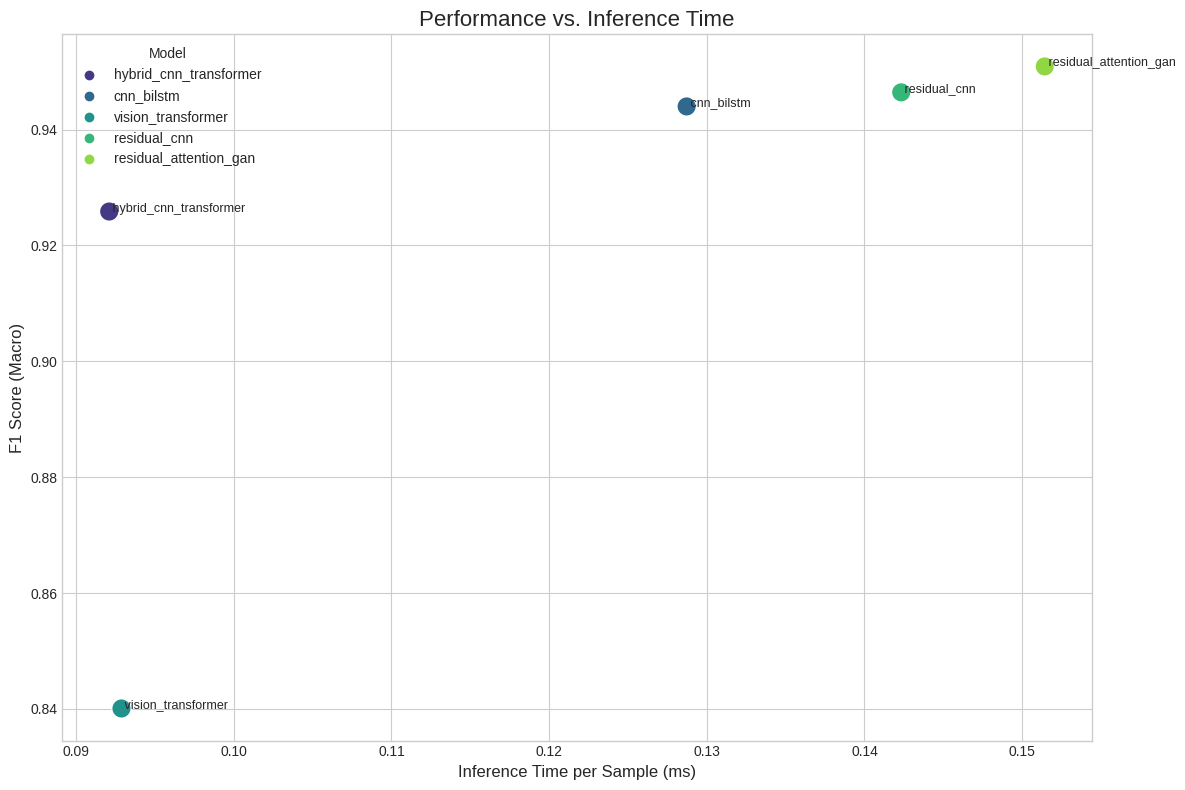

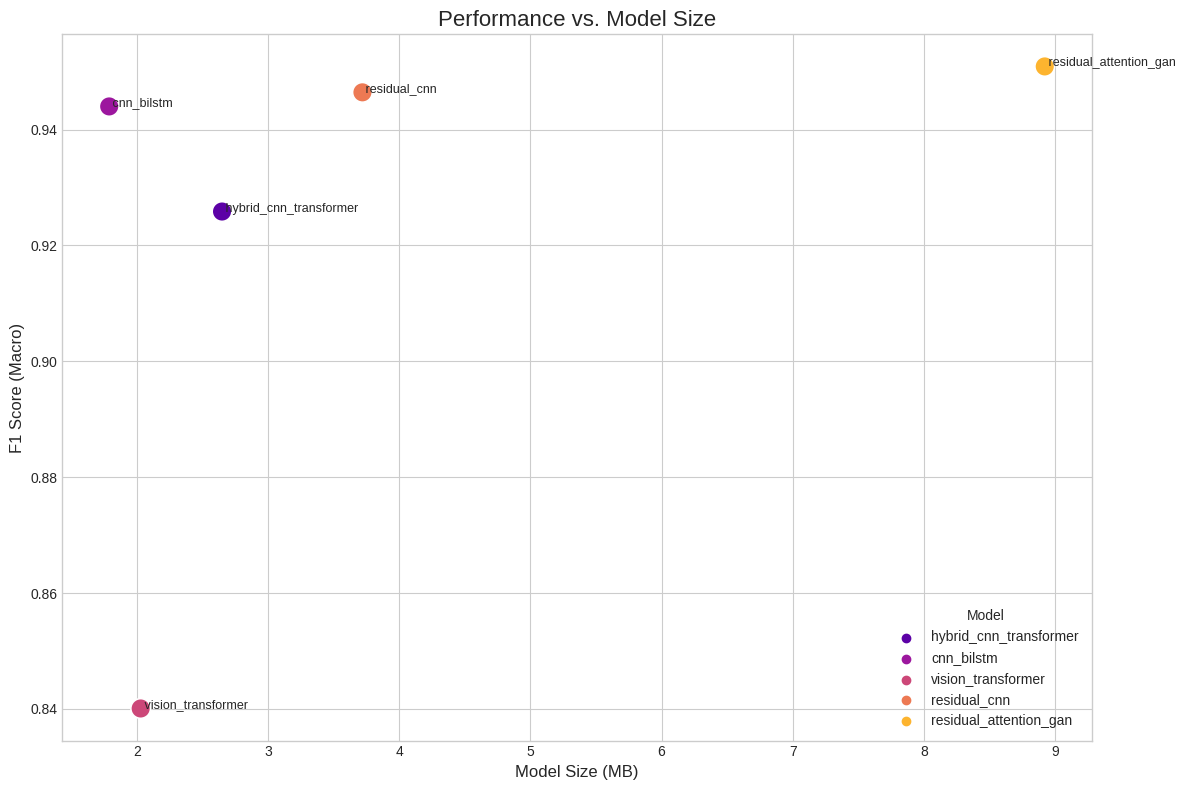


Evaluation summary saved to: /kaggle/working/evaluation_output/evaluation_summary.csv

--- Final Model Ranking ---
               model_name  test_accuracy  f1_macro  precision_macro  \
0  hybrid_cnn_transformer       0.933939  0.925852         0.924572   
1              cnn_bilstm       0.948387  0.943989         0.943505   
2      vision_transformer       0.849250  0.840078         0.835275   
3            residual_cnn       0.952840  0.946423         0.945864   
4  residual_attention_gan       0.956202  0.950894         0.951990   
5            baseline_cnn       0.073421  0.023065         0.018557   

   recall_macro  auc_macro_ovr  num_params  model_size_mb  \
0      0.928676       0.998928      216547           2.65   
1      0.944869       0.999203      148899           1.79   
2      0.850062       0.995393      164643           2.03   
3      0.947460       0.999414      313315           3.72   
4      0.950239       0.999518      764643           8.92   
5      0.058292     

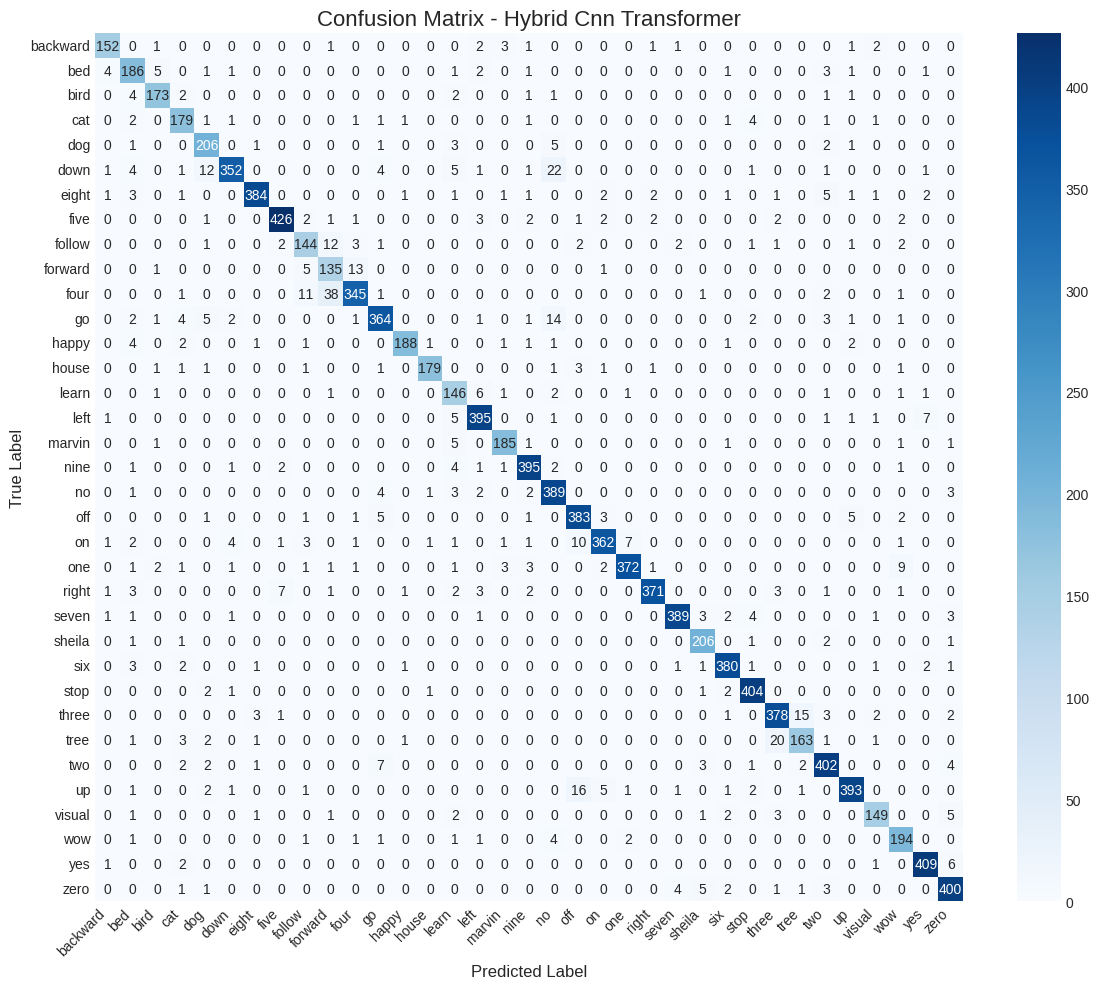

Confusion matrix saved to /kaggle/working/evaluation_output/hybrid_cnn_transformer/confusion_matrix_hybrid_cnn_transformer.png

--- Generating T-SNE plot for hybrid_cnn_transformer ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


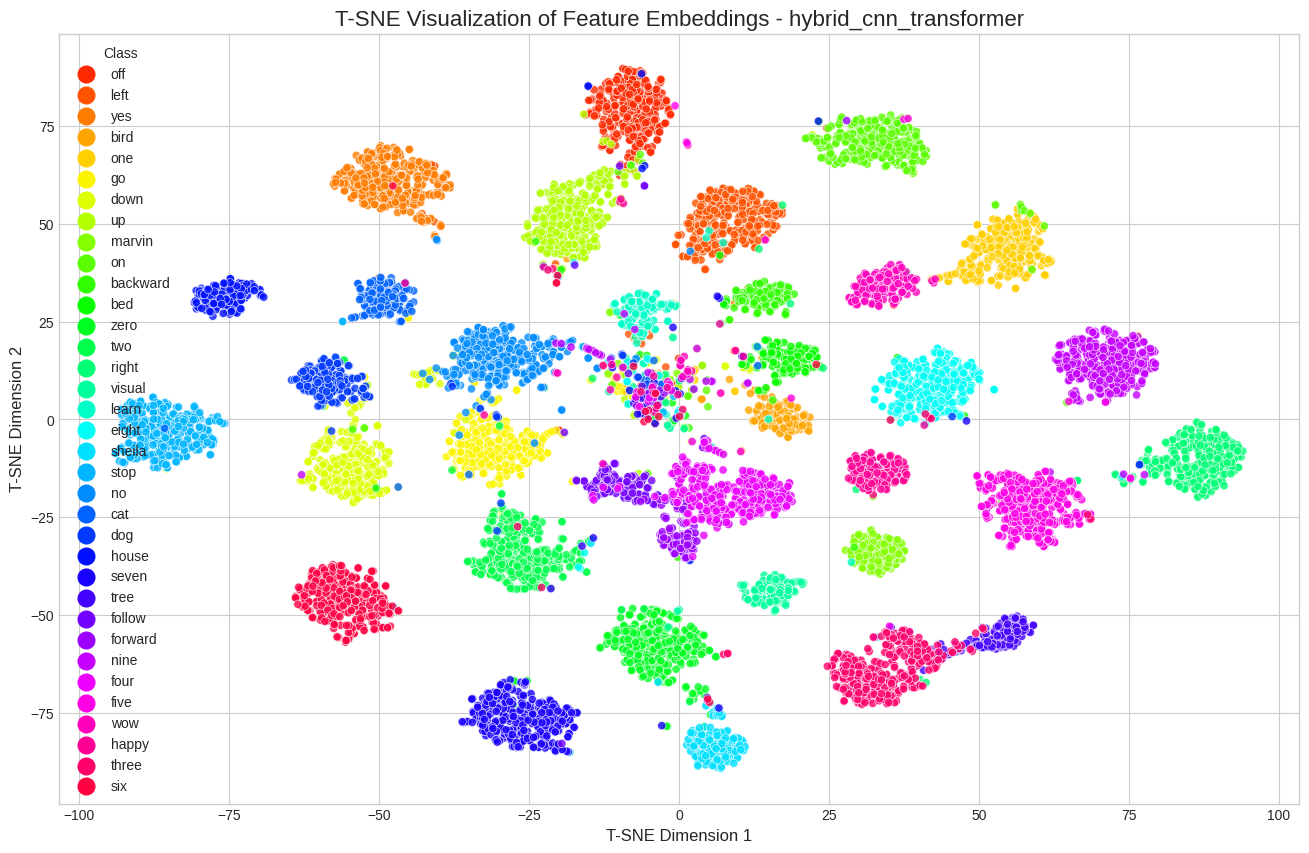

T-SNE plot saved to /kaggle/working/evaluation_output/hybrid_cnn_transformer/tsne_visualization_hybrid_cnn_transformer.png

--- Generating error analysis plots for hybrid_cnn_transformer ---


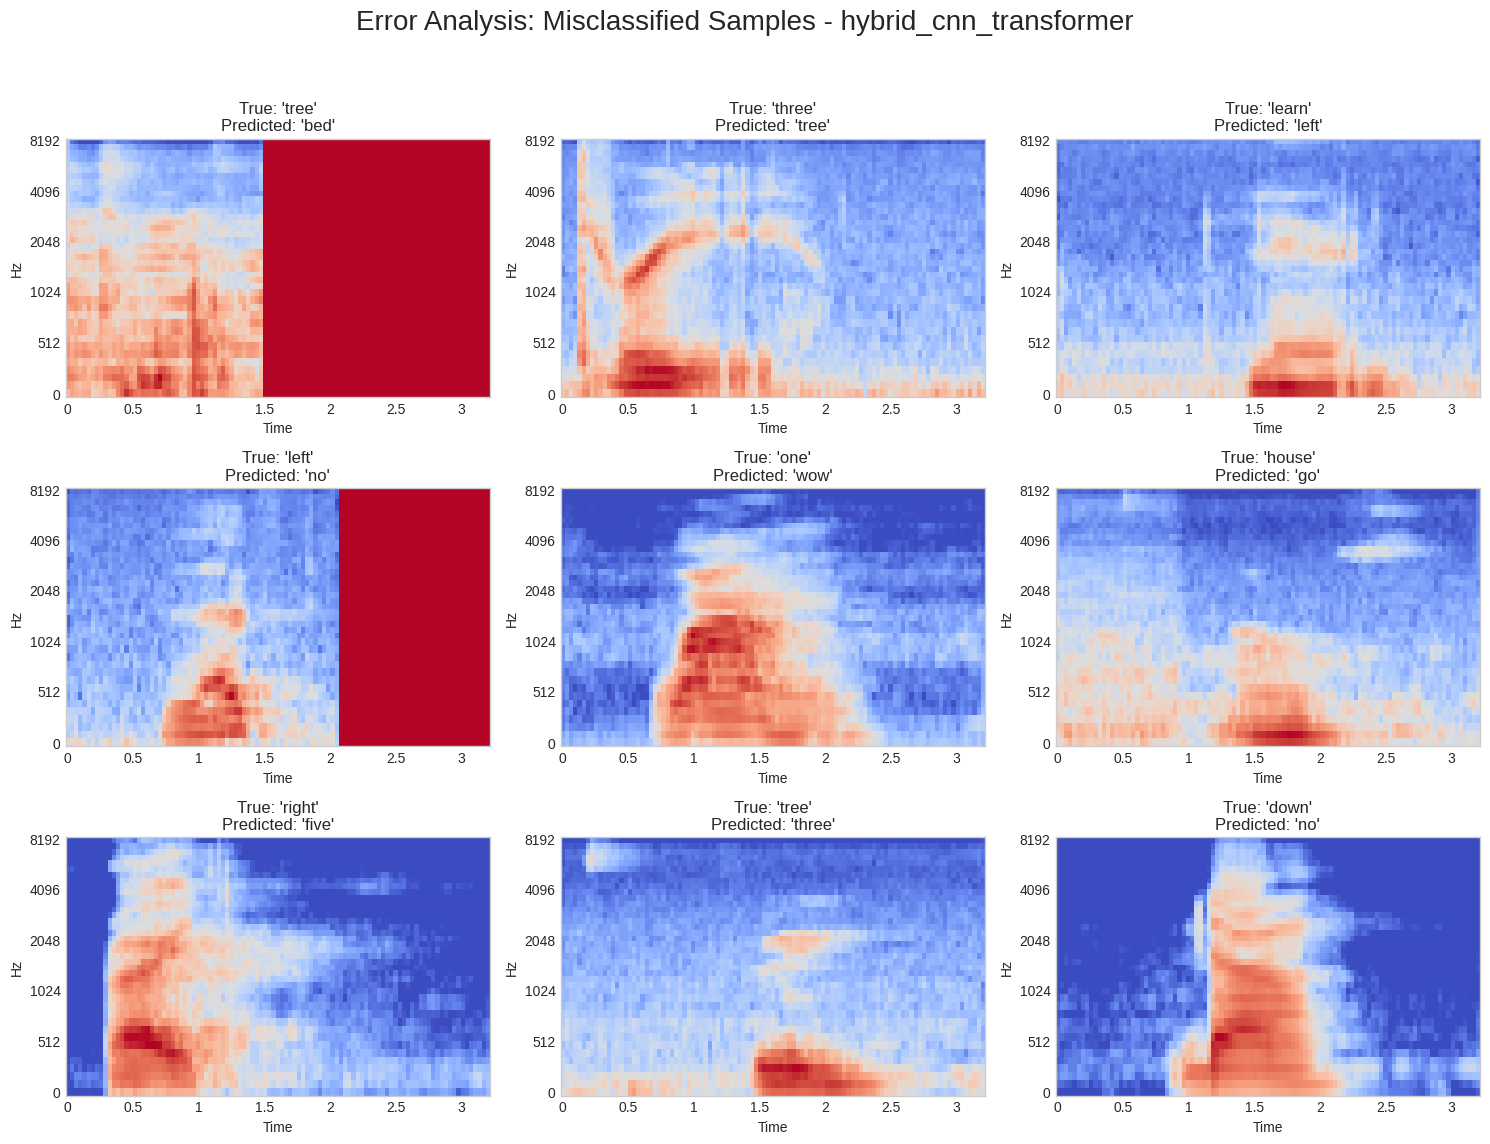

Error analysis plot saved to /kaggle/working/evaluation_output/hybrid_cnn_transformer/error_analysis_hybrid_cnn_transformer.png


In [51]:
evaluator = evaluate_and_compare_models()

best_model_path = run_final_analysis(evaluator)

# Model Conversion to TFLite


In [52]:
# Load the Keras model
model = tf.keras.models.load_model(best_model_path)

# Create a TensorFlow Lite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Default optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save the .tflite file
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

print("Model converted successfully to model.tflite")

Saved artifact at '/tmp/tmp7wj_l7ow'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 101, 1), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 35), dtype=tf.float32, name=None)
Captures:
  138726444161680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138726444162832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138726444163024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138726444162256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138726444160912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138726444162640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138726444163216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138726444165328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138726444165520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138726444164560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1387264441618

W0000 00:00:1754257444.402708      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1754257444.402759      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1754257444.431640      19 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
